# NLP-проект: LLM + RAG для Question Answering и анализа галлюцинаций

**Тема:** исследование влияния Retrieval-Augmented Generation (RAG) на качество ответов и уровень галлюцинаций в задаче question answering.

В ноутбуке сравниваются подходы к одной задаче:

1. **Baseline 1:** TF-IDF retrieval + extractive sentence answer.  
2. **Baseline 2:** LLM без контекста.  
3. **Основной подход:** LLM + RAG.  
4. **Дополнительный вариант:** embedding retrieval + LLM + RAG.  
5. **Расширенный анализ:** метрики QA, популярность информации, язык (русский/английский), размер LLM.

Главный исследовательский вопрос: **уменьшает ли RAG количество галлюцинаций и повышает ли качество ответов по сравнению с LLM без внешнего контекста?**


In [ ]:
# Установка зависимостей для Colab.

import sys
import subprocess

packages = [
    "datasets>=2.19.0,<4.0.0",
    "transformers>=4.45.0,<5.0.0",
    "accelerate>=0.33.0",
    "sentence-transformers>=3.0.0",
    "huggingface_hub>=0.24.0",
    "tqdm>=4.66.0",
]

subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *packages])
print("Зависимости установлены/проверены.")

Зависимости установлены/проверены.


## 1. Hugging Face token

Для публичного датасета и публичной модели токен часто не обязателен, но лучше добавим его в Colab, чтобы загрузка с Hugging Face была стабильнее.

### Как получить HF token

1. Зайти на https://huggingface.co и войти в аккаунт.
2. Открыть профиль.
3. Перейти в `Settings` → `Access Tokens`.
4. Нажать `Create new token`.
5. Выбрать тип доступа **Read**.
6. Скопировать токен.

### Как вставить токен в Colab

1. Слева в Colab нажать на значок ключа `Secrets`.
2. Создать секрет с именем `HF_TOKEN`.
3. Вставить туда токен.
4. Включить доступ секрета для текущего ноутбука.

In [ ]:
import os

HF_TOKEN = None

try:
    from google.colab import userdata
    HF_TOKEN = userdata.get("HF_TOKEN")
except Exception:
    HF_TOKEN = os.environ.get("HF_TOKEN")

if HF_TOKEN:
    os.environ["HF_TOKEN"] = HF_TOKEN
    print("HF_TOKEN найден.")
else:
    print("HF_TOKEN не найден. Для публичных моделей/датасетов это обычно не критично.")

if HF_TOKEN:
    try:
        from huggingface_hub import login
        login(token=HF_TOKEN, add_to_git_credential=False)
        print("Авторизация в Hugging Face выполнена.")
    except Exception as e:
        print("Не удалось выполнить login, но можно попробовать продолжить без него.")
        print(type(e).__name__, e)

HF_TOKEN найден.


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Авторизация в Hugging Face выполнена.


## 2. Импорты и настройки

Важные параметры можно менять здесь.

Для обычного запуска лучше оставлять небольшие значения `N_EVAL_RETRIEVAL` и `N_EVAL_LLM`, чтобы быстрее проверять работоспособность. При необходимости их можно увеличить.

In [ ]:
import re
import gc
import ast
import math
import time
import random
import string
import warnings
from collections import Counter

import numpy as np

# Небольшой fix для окружений, где часть библиотек обращается к np.bool.
try:
    np.bool
except AttributeError:
    np.bool = np.bool_

import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from datasets import load_dataset

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

try:
    from IPython.display import display
except Exception:
    display = print

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DATASET_NAME = "kuznetsoffandrey/sberquad"

# Сколько примеров взять из датасета для работы
MAX_DATASET_EXAMPLES = 1500

# Сколько примеров оценивать для retrieval/baseline экспериментов
N_EVAL_RETRIEVAL = 250

# Сколько примеров оценивать через LLM. LLM — самая медленная часть.
N_EVAL_LLM = 30

# Можно отключить LLM-эксперименты, если нужно быстро проверить только retrieval.
RUN_LLM = True

# Если GPU нет, LLM лучше автоматически отключить, чтобы ноутбук не зависал на CPU.
AUTO_DISABLE_LLM_ON_CPU = True

# Лёгкая instruction-модель.
LLM_MODEL_ID = "Qwen/Qwen2.5-0.5B-Instruct"

# Модель для семантического retrieval.
EMBEDDING_MODEL_ID = "intfloat/multilingual-e5-small"

# Ограничения генерации
MAX_NEW_TOKENS = 64

# Расширенные эксперименты
RUN_EXTENDED_ANALYSIS = True

# Проверка влияния языка: русский SberQuAD + английский SQuAD.
EN_DATASET_CANDIDATES = ["squad", "rajpurkar/squad"]
N_EVAL_LANGUAGE = 20

# Проверка влияния популярности информации: популярные факты vs контекстно-зависимые факты.
N_EVAL_POPULARITY = 8

# Проверка влияния размера модели. 1.5B
RUN_MODEL_SIZE_COMPARISON = True
MODEL_SIZE_COMPARISON_IDS = [
    "Qwen/Qwen2.5-0.5B-Instruct",
    "Qwen/Qwen2.5-1.5B-Instruct",
]
N_EVAL_MODEL_SIZE = 10


print("Настройки:")
print("DATASET_NAME:", DATASET_NAME)
print("MAX_DATASET_EXAMPLES:", MAX_DATASET_EXAMPLES)
print("N_EVAL_RETRIEVAL:", N_EVAL_RETRIEVAL)
print("N_EVAL_LLM:", N_EVAL_LLM)
print("RUN_LLM:", RUN_LLM)
print("LLM_MODEL_ID:", LLM_MODEL_ID)
print("EMBEDDING_MODEL_ID:", EMBEDDING_MODEL_ID)
print("RUN_EXTENDED_ANALYSIS:", RUN_EXTENDED_ANALYSIS)
print("N_EVAL_LANGUAGE:", N_EVAL_LANGUAGE)
print("N_EVAL_MODEL_SIZE:", N_EVAL_MODEL_SIZE)

print("\nВерсии основных библиотек:")
print("numpy:", np.__version__)
print("pandas:", pd.__version__)

import sklearn
print("sklearn:", sklearn.__version__)

Настройки:
DATASET_NAME: kuznetsoffandrey/sberquad
MAX_DATASET_EXAMPLES: 1500
N_EVAL_RETRIEVAL: 250
N_EVAL_LLM: 30
RUN_LLM: True
LLM_MODEL_ID: Qwen/Qwen2.5-0.5B-Instruct
EMBEDDING_MODEL_ID: intfloat/multilingual-e5-small
RUN_EXTENDED_ANALYSIS: True
N_EVAL_LANGUAGE: 20
N_EVAL_MODEL_SIZE: 10

Версии основных библиотек:
numpy: 2.0.2
pandas: 2.2.2
sklearn: 1.6.1


## 3. Загрузка датасета

Используем **SberQuAD** — русскоязычный датасет для Question Answering.

В нём есть:

- `context` — текстовый фрагмент;
- `question` — вопрос;
- `answers` — правильный ответ.


In [ ]:
raw_ds = load_dataset(DATASET_NAME, token=HF_TOKEN if HF_TOKEN else None)
raw_ds

README.md: 0.00B [00:00, ?B/s]

sberquad/train-00000-of-00001.parquet:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

sberquad/validation-00000-of-00001.parqu(…):   0%|          | 0.00/3.43M [00:00<?, ?B/s]

sberquad/test-00000-of-00001.parquet:   0%|          | 0.00/4.93M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/45328 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5036 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/23936 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'title', 'context', 'question', 'answers'],
        num_rows: 45328
    })
    validation: Dataset({
        features: ['id', 'title', 'context', 'question', 'answers'],
        num_rows: 5036
    })
    test: Dataset({
        features: ['id', 'title', 'context', 'question', 'answers'],
        num_rows: 23936
    })
})

In [ ]:
available_splits = list(raw_ds.keys())
print("Доступные split:", available_splits)

# Для экспериментов удобно брать validation: это не train и он меньше полного train.
if "validation" in raw_ds:
    split_name = "validation"
elif "test" in raw_ds:
    split_name = "test"
else:
    split_name = "train"

ds = raw_ds[split_name]
print("Используем split:", split_name)
print("Размер split:", len(ds))
print("Колонки:", ds.column_names)

print("\nПример одной записи из датасета:")
print(ds[0])

Доступные split: ['train', 'validation', 'test']
Используем split: validation
Размер split: 5036
Колонки: ['id', 'title', 'context', 'question', 'answers']

Пример одной записи из датасета:
{'id': 60544, 'title': 'SberChallenge', 'context': 'Первые упоминания о строении человеческого тела встречаются в Древнем Египте. В XXVII веке до н. э. египетский врач Имхотеп описал некоторые органы и их функции, в частности головной мозг, деятельность сердца, распространение крови по сосудам. В древнекитайской книге Нейцзин (XI—VII вв. до н. э.) упоминаются сердце, печень, лёгкие и другие органы тела человека. В индийской книге Аюрведа ( Знание жизни , IX-III вв. до н. э.) содержится большой объём анатомических данных о мышцах, нервах, типах телосложения и темперамента, головном и спинном мозге.', 'question': 'Где встречаются первые упоминания о строении человеческого тела?', 'answers': {'text': ['в Древнем Египте'], 'answer_start': [60]}}


In [ ]:
def unwrap_numpy_object(x):

    if isinstance(x, np.ndarray):
        if x.size == 0:
            return []
        if x.ndim == 0:
            return x.item()
        return x.tolist()
    return x


def is_missing_value(x):
    if x is None:
        return True
    try:
        return bool(pd.isna(x)) and not isinstance(x, (list, tuple, dict, np.ndarray))
    except Exception:
        return False


def get_first_answer(answers):

    answers = unwrap_numpy_object(answers)

    if is_missing_value(answers):
        return ""

    if isinstance(answers, str):
        s = answers.strip()
        if not s:
            return ""
        # Иногда после pandas/parquet объект может стать строковым repr словаря/списка.
        if s.startswith("{") or s.startswith("["):
            try:
                return get_first_answer(ast.literal_eval(s))
            except Exception:
                return s
        return s

    if isinstance(answers, dict):
        text_value = answers.get("text", "")
        text_value = unwrap_numpy_object(text_value)

        if isinstance(text_value, str):
            return text_value.strip()

        if isinstance(text_value, (list, tuple, np.ndarray)):
            text_value = unwrap_numpy_object(text_value)
            for item in text_value:
                item = unwrap_numpy_object(item)
                if isinstance(item, str) and item.strip():
                    return item.strip()
                if isinstance(item, dict):
                    nested = get_first_answer(item)
                    if nested:
                        return nested
            return ""

        if not is_missing_value(text_value):
            return str(text_value).strip()

        return ""

    if isinstance(answers, (list, tuple)):
        for item in answers:
            ans = get_first_answer(item)
            if ans:
                return ans
        return ""

    return str(answers).strip()


work_ds = ds.shuffle(seed=SEED).select(range(min(MAX_DATASET_EXAMPLES, len(ds))))
df_raw = work_ds.to_pandas()

required_cols = ["context", "question", "answers"]
missing_cols = [c for c in required_cols if c not in df_raw.columns]
if missing_cols:
    raise ValueError(f"В датасете нет нужных колонок: {missing_cols}. Текущие колонки: {df_raw.columns.tolist()}")

print("Пример raw answers до извлечения:")
for i in range(min(3, len(df_raw))):
    print(f"[{i}]", repr(df_raw.loc[i, "answers"]))

df = df_raw.copy()
df["answer"] = df["answers"].apply(get_first_answer)

df = df.dropna(subset=["context", "question", "answer"]).copy()
df["context"] = df["context"].astype(str)
df["question"] = df["question"].astype(str)
df["answer"] = df["answer"].astype(str)
df = df[df["answer"].str.strip().str.len() > 0].reset_index(drop=True)
df["context_id"] = df["context"].factorize()[0]

print("\nИтоговый размер df:", len(df))

if len(df) == 0:
    raise ValueError(
        "После извлечения ответов df оказался пустым. "

    )

display(df[["context_id", "question", "answer", "context"]].head(3))

Пример raw answers до извлечения:
[0] {'text': array(['Беспилотное'], dtype=object), 'answer_start': array([0], dtype=int32)}
[1] {'text': array(['Немецкой, чешской и еврейской культур'], dtype=object), 'answer_start': array([104], dtype=int32)}
[2] {'text': array(['У змей кожа меняется одномоментно.'], dtype=object), 'answer_start': array([420], dtype=int32)}

Итоговый размер df: 1500


,context_id,question,answer,context
0,0,"Как называется воздушное судно, выполняющее по...",Беспилотное,"Беспилотное воздушное судно — воздушное судно,..."
1,1,Синтезом каких культур являлась богемская куль...,"Немецкой, чешской и еврейской культур","Богемия была регионом, в котором религиозные и..."
2,2,Как меняется кожа у змей?,У змей кожа меняется одномоментно.,Тело змеи покрыто чешуйчатой кожей. Вопреки ра...


## 4. Анализ данных

Здесь смотрим:

- сколько примеров;
- сколько уникальных контекстов;
- длины контекстов;
- длины вопросов;
- длины ответов.


In [ ]:
def word_len(text):
    return len(str(text).split())


df["context_words"] = df["context"].apply(word_len)
df["question_words"] = df["question"].apply(word_len)
df["answer_words"] = df["answer"].apply(word_len)

stats = pd.DataFrame({
    "metric": [
        "examples",
        "unique_contexts",
        "mean_context_words",
        "median_context_words",
        "mean_question_words",
        "mean_answer_words",
    ],
    "value": [
        len(df),
        df["context_id"].nunique(),
        round(df["context_words"].mean(), 2),
        round(df["context_words"].median(), 2),
        round(df["question_words"].mean(), 2),
        round(df["answer_words"].mean(), 2),
    ]
})

display(stats)

,metric,value
0,examples,1500.00
1,unique_contexts,1387.00
2,mean_context_words,101.27
3,median_context_words,92.00
4,mean_question_words,8.72
5,mean_answer_words,3.72


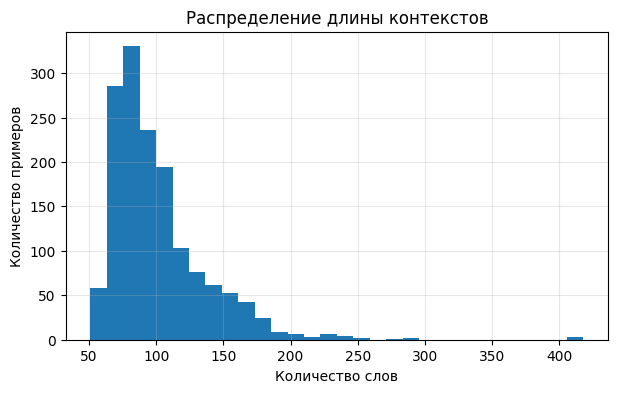

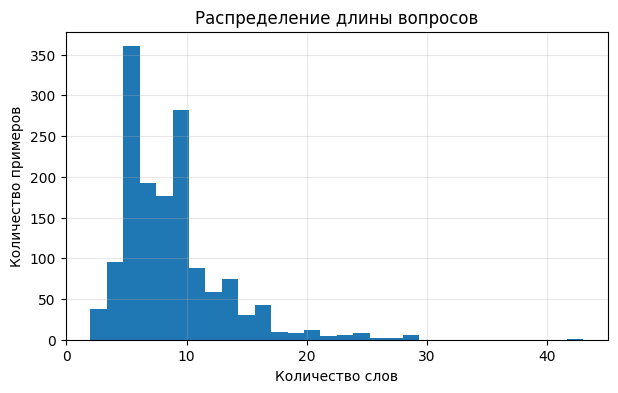

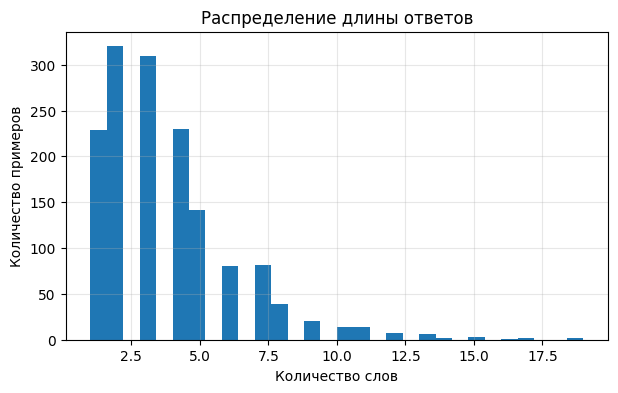

In [ ]:
for col, title in [
    ("context_words", "Распределение длины контекстов"),
    ("question_words", "Распределение длины вопросов"),
    ("answer_words", "Распределение длины ответов"),
]:
    plt.figure(figsize=(7, 4))
    plt.hist(df[col], bins=30)
    plt.title(title)
    plt.xlabel("Количество слов")
    plt.ylabel("Количество примеров")
    plt.grid(alpha=0.3)
    plt.show()

In [ ]:
# Примеры данных
n_samples = min(3, len(df))
sample_examples = df[["question", "answer", "context"]].sample(n_samples, random_state=SEED)
pd.set_option("display.max_colwidth", 250)
display(sample_examples)

,question,answer,context
1116,Кто сочетает в себе образы своих сёнэн-предшественников ?,Наруто Удзумаки,"По мнению рецензента сайта T.H.E.M. Anime Reviews персонажи Наруто являются отражением царящих в сёнэн-манге стереотипов и некоторые из них даже не симпатичны[37]. Однако другой обзор этого же сайта оценивает мангу в более радужных тонах, отмечая..."
1368,Какие исследования выпускают независимые аналитические агентства?,"по акциям компаний, валютному рынку, деривативам, вкладам, ПИФам","Таким образом, основными предпосылками появления независимой аналитики было растущее недоверие инвесторов к аналитике, выпускаемой штатными подразделениями инвестиционных банков и брокеров, а также понимание необходимости регулирования ситуации н..."
422,Рекорд на скольких метрах поставила Марита Кох (ГДР)?,400,"Значительное количество мировых рекордов в лёгкой атлетике вызывает законные подозрения специалистов, хотя атлеты не были пойманы и сами не признались. Особенно это касается женской лёгкой атлетики. К таковым относится мировой рекорд на 400 м Мар..."


### Промежуточный вывод по данным

В работе использовался русскоязычный QA-датасет **SberQuAD**. Для экспериментов был выбран split `validation`, из которого взято **1500 примеров**. После обработки в датасете осталось **1500 корректных записей**, то есть парсер ответов успешно извлёк ответы из поля `answers`. Всего в выбранной подвыборке оказалось **1387 уникальных контекстов**.

По статистике видно, что средний контекст содержит примерно **101 слово**, медианная длина контекста — **92 слова**. Вопросы в среднем короткие — примерно **8.72 слова**, а ответы обычно являются небольшими фрагментами текста — примерно **3.72 слова**. Это хорошо подходит для задачи extractive question answering: правильный ответ чаще всего является коротким span-фрагментом внутри контекста.

Для RAG были выбраны размеры чанков **200, 300 и 500 слов**. Такие значения выглядят обоснованными: средний контекст целиком помещается в один чанк, но для более длинных текстов чанкинг с overlap позволяет не потерять нужный фрагмент на границе чанков. Поэтому на этапе retrieval модель получает достаточно полный, но не чрезмерно длинный контекст.

## 5. Предобработка и метрики QA

В этой работе задача является **Question Answering**, поэтому обычной accuracy здесь недостаточно: ответ может быть не полностью идентичен эталону, но частично совпадать с ним по смыслу или словам. Поэтому используем несколько метрик.

| Метрика | Что измеряет | Зачем нужна | Ограничение |
|---|---|---|---|
| **Exact Match (EM)** | Полное совпадение нормализованного ответа с эталоном | Строгая проверка точного ответа | Слишком жёсткая для генеративных ответов |
| **Token F1** | Пересечение токенов между предсказанием и эталоном | Показывает частичную правильность ответа | Не всегда понимает синонимы и смысл |
| **retrieved_contains_answer_rate / Recall@k** | Попал ли правильный ответ в найденные top-k чанки | Оценивает качество retrieval-части RAG | Не оценивает качество финальной генерации |
| **correct_context_retrieved_rate** | Найден ли исходный контекст вопроса | Помогает понять, находит ли retrieval нужный документ | Документ может быть правильным, но нужный span может отсутствовать в чанке |
| **hallucination_like_rate** | Доля ответов с низким F1, если модель не отказалась от ответа | Приближённо оценивает потенциальные галлюцинации | Это не ручная фактологическая проверка, а автоматическая эвристика |
| **refusal_rate** | Доля ответов вида “нет информации” | Показывает осторожность модели | Модель может отказываться даже при наличии ответа |

Важно: автоматическая оценка галлюцинаций не идеальна. Поэтому после таблиц дополнительно выполняется **анализ ошибок вручную**: смотрим конкретные вопросы, правильные ответы, ответы модели и найденный RAG-контекст.


In [ ]:
RU_PUNCT = string.punctuation + "«»“”„…—–"


def normalize_text(text):
    text = str(text).lower().replace("ё", "е")
    text = re.sub(f"[{re.escape(RU_PUNCT)}]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def tokenize_norm(text):
    return normalize_text(text).split()


def exact_match(pred, gold):
    return int(normalize_text(pred) == normalize_text(gold))


def token_f1(pred, gold):
    pred_tokens = tokenize_norm(pred)
    gold_tokens = tokenize_norm(gold)

    if len(pred_tokens) == 0 and len(gold_tokens) == 0:
        return 1.0
    if len(pred_tokens) == 0 or len(gold_tokens) == 0:
        return 0.0

    common = Counter(pred_tokens) & Counter(gold_tokens)
    num_same = sum(common.values())

    if num_same == 0:
        return 0.0

    precision = num_same / len(pred_tokens)
    recall = num_same / len(gold_tokens)
    return 2 * precision * recall / (precision + recall)


def contains_answer(text, answer):
    return normalize_text(answer) in normalize_text(text)


def is_no_info_answer(pred):
    p = normalize_text(pred)
    patterns = [
        "нет информации",
        "не указано",
        "неизвестно",
        "в контексте нет",
        "нет данных",
        "я не знаю",
        "не могу ответить",
        "no information",
        "not enough information",
        "unknown",
        "i don t know",
        "cannot answer",
        "not provided",
        "not mentioned",
        "context does not"
    ]
    return any(x in p for x in patterns)


def hallucination_like(pred, gold, f1_threshold=0.20):
    if is_no_info_answer(pred):
        return 0
    return int(token_f1(pred, gold) < f1_threshold)


def evaluate_predictions(rows):
    out = []
    for r in rows:
        pred = str(r.get("prediction", ""))
        gold = str(r.get("answer", ""))
        f1 = token_f1(pred, gold)
        em = exact_match(pred, gold)
        out.append({
            **r,
            "em": em,
            "f1": f1,
            "hallucination_like": hallucination_like(pred, gold),
        })
    return pd.DataFrame(out)


def aggregate_metrics(eval_df, method_name, extra=None):
    extra = extra or {}
    result = {
        "method": method_name,
        "n": len(eval_df),
        "em": round(float(eval_df["em"].mean()), 4) if len(eval_df) else np.nan,
        "f1": round(float(eval_df["f1"].mean()), 4) if len(eval_df) else np.nan,
        "hallucination_like_rate": round(float(eval_df["hallucination_like"].mean()), 4) if len(eval_df) else np.nan,
        "refusal_rate": round(float(eval_df["prediction"].apply(is_no_info_answer).mean()), 4) if len(eval_df) and "prediction" in eval_df.columns else np.nan,
        "avg_prediction_words": round(float(eval_df["prediction"].astype(str).apply(lambda x: len(x.split())).mean()), 2) if len(eval_df) and "prediction" in eval_df.columns else np.nan,
    }
    for col in ["retrieved_contains_answer", "correct_context_retrieved"]:
        if col in eval_df.columns:
            result[col + "_rate"] = round(float(eval_df[col].mean()), 4)
    result.update(extra)
    return result


# Быстрая проверка метрик
print("EM test:", exact_match("Елена Мартынова", "Елена Мартынова"))
print("F1 test:", round(token_f1("руководителем была Елена Мартынова", "Елена Мартынова"), 3))

EM test: 1
F1 test: 0.667


### 5.1. Как интерпретировать метрики в проекте

Для итогового сравнения основной метрикой будет **Token F1**, потому что она мягче, чем Exact Match, и лучше подходит для генеративных ответов. При этом **EM** сохраняется как строгая метрика: она показывает, когда модель дала почти ровно тот же ответ, что и в датасете.

Для RAG отдельно важен **Recall@k** (`retrieved_contains_answer_rate`): если правильный ответ не попал в найденные чанки, LLM почти не имеет шансов ответить корректно. Поэтому RAG оценивается как двухэтапная система: сначала качество поиска, затем качество генерации.

`hallucination_like_rate` в этой работе используется как автоматическая приближённая метрика: если модель дала ответ, но он почти не совпадает с эталоном, такой ответ помечается как потенциально галлюцинаторный. Это не идеальная ручная проверка фактов, а эвристика для массового сравнения подходов.


In [ ]:
metric_examples = pd.DataFrame([
    {
        "prediction": "Елена Мартынова",
        "answer": "Елена Мартынова",
        "comment": "точное совпадение",
    },
    {
        "prediction": "руководителем проекта была Елена Мартынова",
        "answer": "Елена Мартынова",
        "comment": "смысл верный, но ответ длиннее",
    },
    {
        "prediction": "Александр Иванов",
        "answer": "Елена Мартынова",
        "comment": "неподтверждённый/ошибочный ответ",
    },
    {
        "prediction": "Нет информации в контексте",
        "answer": "Елена Мартынова",
        "comment": "отказ от ответа",
    },
])

metric_examples["EM"] = metric_examples.apply(lambda r: exact_match(r["prediction"], r["answer"]), axis=1)
metric_examples["Token F1"] = metric_examples.apply(lambda r: round(token_f1(r["prediction"], r["answer"]), 3), axis=1)
metric_examples["hallucination_like"] = metric_examples.apply(lambda r: hallucination_like(r["prediction"], r["answer"]), axis=1)
metric_examples["is_refusal"] = metric_examples["prediction"].apply(is_no_info_answer)

display(metric_examples)


,prediction,answer,comment,EM,Token F1,hallucination_like,is_refusal
0,Елена Мартынова,Елена Мартынова,точное совпадение,1,1.000,0,False
1,руководителем проекта была Елена Мартынова,Елена Мартынова,"смысл верный, но ответ длиннее",0,0.571,0,False
2,Александр Иванов,Елена Мартынова,неподтверждённый/ошибочный ответ,0,0.000,1,False
3,Нет информации в контексте,Елена Мартынова,отказ от ответа,0,0.000,0,True


## 6. Чанкинг документов

RAG обычно не работает с полным корпусом целиком. Документы режут на части — **чанки**.

В экспериментах будем менять:

- `chunk_size`;
- `top_k`;
- тип retrieval;
- тип prompt.

In [ ]:
def chunk_text_by_words(text, chunk_size=300, overlap=50):
    words = str(text).split()
    if len(words) <= chunk_size:
        return [str(text)]

    chunks = []
    step = max(1, chunk_size - overlap)
    for start in range(0, len(words), step):
        chunk = " ".join(words[start:start + chunk_size])
        if chunk.strip():
            chunks.append(chunk)
        if start + chunk_size >= len(words):
            break
    return chunks


def build_chunk_corpus(df_source, chunk_size=300, overlap=50):
    unique_contexts = (
        df_source[["context_id", "context"]]
        .drop_duplicates("context_id")
        .reset_index(drop=True)
    )

    chunks = []
    for _, row in unique_contexts.iterrows():
        parts = chunk_text_by_words(row["context"], chunk_size=chunk_size, overlap=overlap)
        for i, part in enumerate(parts):
            chunks.append({
                "chunk_id": len(chunks),
                "context_id": int(row["context_id"]),
                "chunk_index": i,
                "text": part,
                "chunk_size": chunk_size,
                "overlap": overlap,
            })
    return pd.DataFrame(chunks)


test_chunks = build_chunk_corpus(df, chunk_size=300, overlap=50)
print("Количество чанков:", len(test_chunks))
display(test_chunks.head())

Количество чанков: 1388


,chunk_id,context_id,chunk_index,text,chunk_size,overlap
0,0,0,0,"Беспилотное воздушное судно — воздушное судно, которое предназначено выполнять полет без пилота на борту.[18] Беспилотная авиационная система — Воздушное судно и связанные с ним элементы, которые эксплуатируются без пилота на борту. Автономное во...",300,50
1,1,1,0,"Богемия была регионом, в котором религиозные и этнические контрасты были тесно переплетены друг с другом. Таким образом, богемская культура являлась синтезом немецкой, чешской и еврейской культур. Такие писатели, как Адальберт Штифтер, Райнер Мар...",300,50
2,2,2,0,"Тело змеи покрыто чешуйчатой кожей. Вопреки расхожему мнению (из-за возможной путаницы змей с червями) змеиная кожа сухая, а не влажная и слизистая. У большинства видов змей кожа со стороны живота особая и приспособлена для большего сцепления с п...",300,50
3,3,3,0,"Неудачный опыт сотрудничества со Скорпионом заставил Бунина отказаться от дальнейшей работы с символистским издательством; как писал сам Иван Алексеевич, в определённый момент он утратил желание играть с новыми сотоварищами в аргонавтов, в демоно...",300,50
4,4,4,0,К самым древним дорогам Рима относятся Аппиева дорога (312—244 годы до н. э.) и Фламиниева дорога (220 год до н. э.). Римские дороги строились с целью увеличения скорости передвижения войск и торговых караванов. Дорожная сеть в Риме разрасталась ...,300,50


## 7. Baseline 1: TF-IDF retrieval + extractive sentence answer

Question Answering по тексту можно начать решать через информационный поиск. Если вопрос содержит слова, близкие к словам в релевантном контексте, TF-IDF должен найти нужный фрагмент.

**Pipeline baseline:**

1. Каждый контекст режется на чанки.
2. По чанкам строится TF-IDF матрица.
3. Для вопроса ищутся top-k самых похожих чанков.
4. Из найденных чанков выбирается предложение, наиболее похожее на вопрос.
5. Это предложение считается ответом.

Этот метод не использует LLM и нужен как понятная точка отсчёта. Его ограничение: он часто возвращает длинный фрагмент, а не короткий точный ответ.


In [ ]:
class TfidfRetriever:
    def __init__(self):
        self.vectorizer = TfidfVectorizer(
            lowercase=True,
            max_features=50_000,
            ngram_range=(1, 2),
            min_df=1,
        )
        self.chunks_df = None
        self.matrix = None

    def fit(self, chunks_df):
        self.chunks_df = chunks_df.reset_index(drop=True).copy()
        self.matrix = self.vectorizer.fit_transform(self.chunks_df["text"].tolist())
        return self

    def search(self, query, top_k=3):
        q_vec = self.vectorizer.transform([query])
        scores = cosine_similarity(q_vec, self.matrix).ravel()
        top_idx = np.argsort(scores)[::-1][:top_k]

        results = []
        for idx in top_idx:
            row = self.chunks_df.iloc[int(idx)].to_dict()
            row["score"] = float(scores[idx])
            results.append(row)
        return results


def split_sentences_ru(text):
    text = str(text)
    parts = re.split(r"(?<=[.!?])\s+", text)
    parts = [p.strip() for p in parts if len(p.strip()) > 0]
    return parts if parts else [text]


def choose_best_sentence(question, text):
    sentences = split_sentences_ru(text)
    if len(sentences) == 1:
        return sentences[0]

    local_vectorizer = TfidfVectorizer(lowercase=True, ngram_range=(1, 2), min_df=1)
    try:
        matrix = local_vectorizer.fit_transform([question] + sentences)
        scores = cosine_similarity(matrix[0:1], matrix[1:]).ravel()
        return sentences[int(np.argmax(scores))]
    except Exception:
        return sentences[0]


def evaluate_tfidf_baseline(df_eval, chunk_size=300, overlap=50, top_k=1):
    chunks_df = build_chunk_corpus(df, chunk_size=chunk_size, overlap=overlap)
    retriever = TfidfRetriever().fit(chunks_df)

    rows = []
    for _, row in tqdm(df_eval.iterrows(), total=len(df_eval), desc="TF-IDF baseline"):
        retrieved = retriever.search(row["question"], top_k=top_k)
        retrieved_text = "\n".join([r["text"] for r in retrieved])
        pred = choose_best_sentence(row["question"], retrieved_text)

        rows.append({
            "id": row.get("id", None),
            "context_id": int(row["context_id"]),
            "question": row["question"],
            "answer": row["answer"],
            "prediction": pred,
            "retrieved_text": retrieved_text,
            "retrieved_contains_answer": int(any(contains_answer(r["text"], row["answer"]) for r in retrieved)),
            "correct_context_retrieved": int(any(int(r["context_id"]) == int(row["context_id"]) for r in retrieved)),
            "chunk_size": chunk_size,
            "top_k": top_k,
        })

    return evaluate_predictions(rows)

In [ ]:
eval_df = df.sample(min(N_EVAL_RETRIEVAL, len(df)), random_state=SEED).reset_index(drop=True)
llm_eval_df = eval_df.head(min(N_EVAL_LLM, len(eval_df))).copy()

print("Размер eval_df для быстрых экспериментов:", len(eval_df))
print("Размер llm_eval_df для LLM-экспериментов:", len(llm_eval_df))

Размер eval_df для быстрых экспериментов: 250
Размер llm_eval_df для LLM-экспериментов: 30


In [ ]:
tfidf_eval_300_k1 = evaluate_tfidf_baseline(eval_df, chunk_size=300, overlap=50, top_k=1)

display(tfidf_eval_300_k1[["question", "answer", "prediction", "f1", "em", "retrieved_contains_answer"]].head())

baseline_metrics = aggregate_metrics(
    tfidf_eval_300_k1,
    "TF-IDF sentence baseline",
    {"retriever": "tfidf", "chunk_size": 300, "top_k": 1, "prompt_type": "-", "temperature": "-"}
)
baseline_metrics

TF-IDF baseline:   0%|          | 0/250 [00:00<?, ?it/s]

,question,answer,prediction,f1,em,retrieved_contains_answer
0,Кто сочетает в себе образы своих сёнэн-предшественников ?,Наруто Удзумаки,"Однако другой обзор этого же сайта оценивает мангу в более радужных тонах, отмечая, что Наруто Удзумаки сочетает в себе образы своих сёнэн-предшественников , но сетуя, что некоторые персонажи находятся между харизмой и хладнокровием Наруто и невы...",0.076923,0,1
1,Какие исследования выпускают независимые аналитические агентства?,"по акциям компаний, валютному рынку, деривативам, вкладам, ПИФам","Независимые аналитические агентства берут на себя поддерживающую рынок роль и выпускают исследования по акциям компаний, валютному рынку, деривативам, вкладам, ПИФам, товарным рынкам, частным инвестициям.",0.500000,0,1
2,Рекорд на скольких метрах поставила Марита Кох (ГДР)?,400,"К таковым относится мировой рекорд на 400 м Мариты Кох (ГДР), Рекорды на 100 и 200 метров Флоренс Гриффит-Джойнер, рекорд на 3000 м и 10 000 м.",0.068966,0,1
3,Кем работал Пьер Кюри на момент встречи с Склодовской?,руководителем лаборатории,В 1903 году Мария и Пьер Кюри совместно с Анри Беккерелем получили Нобелевскую премию по физике за выдающиеся заслуги в совместных исследованиях явлений радиации .,0.000000,0,0
4,На какие марки подразделяется висмут?,"Ви2, Ви1, Ви00, Ви000[13], Ви0000",Средневзвешенная цена на мировом рынке на конец 2016 г.,0.000000,0,1


{'method': 'TF-IDF sentence baseline',
 'n': 250,
 'em': 0.0,
 'f1': 0.212,
 'hallucination_like_rate': 0.568,
 'refusal_rate': 0.0,
 'avg_prediction_words': 21.29,
 'retrieved_contains_answer_rate': 0.744,
 'correct_context_retrieved_rate': 0.744,
 'retriever': 'tfidf',
 'chunk_size': 300,
 'top_k': 1,
 'prompt_type': '-',
 'temperature': '-'}

### Промежуточный вывод по baseline

TF-IDF baseline был оценён на **250 примерах**. Метод показал качество нижнего уровня для сравнения с LLM-подходами. Лучший вариант TF-IDF baseline получился при `chunk_size=300` или `chunk_size=500` и `top_k=3`: **EM = 0.004**, **Token F1 = 0.2346**, `retrieved_contains_answer_rate = 0.88`, `hallucination_like_rate = 0.516`.

Результат показывает, что простое лексическое извлечение достаточно часто находит правильный фрагмент: при `top_k=3` правильный ответ содержался в найденном контексте в **88%** случаев. Однако качество итогового ответа остаётся невысоким, потому что baseline возвращает не точный короткий ответ, а наиболее похожее предложение или фрагмент. Из-за этого Exact Match почти нулевой, а Token F1 остаётся около **0.21–0.23**.

Таким образом, TF-IDF baseline полезен как простой и интерпретируемый ориентир: он хорошо показывает, насколько далеко можно продвинуться только за счёт поиска похожего текста, но без генеративной модели ответ получается слишком грубым.

## 8. Baseline 2 и основной метод: LLM без RAG и LLM + RAG

Здесь загружается небольшая instruction-модель `Qwen/Qwen2.5-0.5B-Instruct`.

### Baseline 2: LLM без RAG

LLM умеет генерировать ответы на естественном языке и может отвечать на вопросы напрямую. Это полезный baseline, чтобы проверить, насколько модель полагается на внутренние знания.

**Pipeline:** вопрос → prompt → LLM → ответ.

**Ограничение:** модель не видит исходный контекст датасета, поэтому может отвечать “из памяти” и выдумывать факты.

### Основной метод: LLM + RAG

в QA по документам ответ должен опираться на конкретный текст. RAG сначала находит релевантные фрагменты, а затем LLM формулирует ответ на основе найденного контекста.

**Pipeline:** вопрос → retrieval top-k чанков → prompt с контекстом → LLM → ответ.

**Ограничение:** если retrieval нашёл неверный или неполный контекст, LLM может всё равно ошибиться. Поэтому отдельно оцениваем как retrieval, так и финальный ответ.

Если GPU не включён и `AUTO_DISABLE_LLM_ON_CPU=True`, LLM-часть будет отключена, чтобы ноутбук не зависал.


In [ ]:
def check_torch_device():
    try:
        import torch
        if torch.cuda.is_available():
            print("GPU доступен:", torch.cuda.get_device_name(0))
            return "cuda"
        print("GPU не найден.")
        return "cpu"
    except Exception as e:
        print("Не удалось импортировать torch:", type(e).__name__, e)
        return "unknown"


device_type = check_torch_device()

if AUTO_DISABLE_LLM_ON_CPU and device_type != "cuda":
    print("LLM-часть автоматически отключена, потому что GPU не найден.")
    RUN_LLM = False

print("RUN_LLM:", RUN_LLM)

GPU доступен: Tesla T4
RUN_LLM: True


In [ ]:
llm_tokenizer = None
llm_model = None


def load_llm_model():
    global llm_tokenizer, llm_model

    if not RUN_LLM:
        print("RUN_LLM=False, модель не загружается.")
        return None, None

    import torch
    from transformers import AutoTokenizer, AutoModelForCausalLM

    dtype = torch.float16 if torch.cuda.is_available() else torch.float32

    print("Загружаю LLM:", LLM_MODEL_ID)
    llm_tokenizer = AutoTokenizer.from_pretrained(
        LLM_MODEL_ID,
        token=HF_TOKEN if HF_TOKEN else None,
        trust_remote_code=True,
    )

    llm_model = AutoModelForCausalLM.from_pretrained(
        LLM_MODEL_ID,
        token=HF_TOKEN if HF_TOKEN else None,
        torch_dtype=dtype,
        device_map="auto",
        trust_remote_code=True,
    )

    if llm_tokenizer.pad_token is None:
        llm_tokenizer.pad_token = llm_tokenizer.eos_token

    llm_model.eval()
    print("LLM загружена.")
    return llm_tokenizer, llm_model


try:
    llm_tokenizer, llm_model = load_llm_model()
except Exception as e:
    print("Не удалось загрузить LLM. LLM-эксперименты будут пропущены.")
    print(type(e).__name__, e)
    RUN_LLM = False

Загружаю LLM: Qwen/Qwen2.5-0.5B-Instruct


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

LLM загружена.


In [ ]:
def generate_llm_response(prompt, temperature=0.0, max_new_tokens=MAX_NEW_TOKENS):
    if not RUN_LLM or llm_model is None or llm_tokenizer is None:
        return "LLM_DISABLED"

    import torch

    messages = [
        {"role": "system", "content": "Ты помощник для точного ответа на вопросы. Отвечай кратко."},
        {"role": "user", "content": prompt},
    ]

    if hasattr(llm_tokenizer, "apply_chat_template"):
        text = llm_tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True,
        )
    else:
        text = prompt

    inputs = llm_tokenizer(text, return_tensors="pt").to(llm_model.device)

    do_sample = temperature is not None and float(temperature) > 0

    with torch.no_grad():
        output_ids = llm_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=do_sample,
            temperature=float(temperature) if do_sample else None,
            pad_token_id=llm_tokenizer.eos_token_id,
        )

    generated = output_ids[0][inputs["input_ids"].shape[-1]:]
    answer = llm_tokenizer.decode(generated, skip_special_tokens=True)
    answer = answer.strip()
    answer = re.sub(r"\s+", " ", answer)
    return answer


def make_no_rag_prompt(question, prompt_type="plain"):
    if prompt_type == "strict":
        return (
            "Ответь на вопрос кратко. Если ты не уверен в ответе, напиши: Нет информации.\n\n"
            f"Вопрос: {question}\nОтвет:"
        )
    return f"Ответь на вопрос кратко.\n\nВопрос: {question}\nОтвет:"


def make_rag_prompt(question, context, prompt_type="strict"):
    if prompt_type == "strict":
        return (
            "Ответь на вопрос только на основе контекста ниже. "
            "Если в контексте нет ответа, напиши: Нет информации в контексте.\n\n"
            f"Контекст:\n{context}\n\n"
            f"Вопрос:\n{question}\n\n"
            "Ответ:"
        )
    return (
        f"Контекст:\n{context}\n\n"
        f"Вопрос:\n{question}\n\n"
        "Ответь кратко:"
    )

In [ ]:
def evaluate_llm_no_rag(df_eval, prompt_type="plain", temperature=0.0):
    rows = []
    if not RUN_LLM:
        return pd.DataFrame()

    for _, row in tqdm(df_eval.iterrows(), total=len(df_eval), desc="LLM no RAG"):
        prompt = make_no_rag_prompt(row["question"], prompt_type=prompt_type)
        pred = generate_llm_response(prompt, temperature=temperature)
        rows.append({
            "context_id": int(row["context_id"]),
            "question": row["question"],
            "answer": row["answer"],
            "prediction": pred,
            "prompt_type": prompt_type,
            "temperature": temperature,
        })
    return evaluate_predictions(rows)


def evaluate_llm_rag_tfidf(df_eval, chunk_size=300, overlap=50, top_k=3, prompt_type="strict", temperature=0.0):
    rows = []
    if not RUN_LLM:
        return pd.DataFrame()

    chunks_df = build_chunk_corpus(df, chunk_size=chunk_size, overlap=overlap)
    retriever = TfidfRetriever().fit(chunks_df)

    for _, row in tqdm(df_eval.iterrows(), total=len(df_eval), desc="LLM + TF-IDF RAG"):
        retrieved = retriever.search(row["question"], top_k=top_k)
        context = "\n\n".join([r["text"] for r in retrieved])
        prompt = make_rag_prompt(row["question"], context, prompt_type=prompt_type)
        pred = generate_llm_response(prompt, temperature=temperature)

        rows.append({
            "context_id": int(row["context_id"]),
            "question": row["question"],
            "answer": row["answer"],
            "prediction": pred,
            "retrieved_text": context,
            "retrieved_contains_answer": int(any(contains_answer(r["text"], row["answer"]) for r in retrieved)),
            "correct_context_retrieved": int(any(int(r["context_id"]) == int(row["context_id"]) for r in retrieved)),
            "chunk_size": chunk_size,
            "top_k": top_k,
            "prompt_type": prompt_type,
            "temperature": temperature,
        })

    return evaluate_predictions(rows)

In [ ]:
# Быстрая демонстрация на одном примере
if RUN_LLM and len(llm_eval_df) > 0:
    demo_row = llm_eval_df.iloc[0]
    demo_question = demo_row["question"]
    demo_answer = demo_row["answer"]

    print("Вопрос:", demo_question)
    print("Правильный ответ:", demo_answer)

    print("\nLLM без RAG:")
    print(generate_llm_response(make_no_rag_prompt(demo_question), temperature=0.0))

    demo_chunks = build_chunk_corpus(df, chunk_size=300, overlap=50)
    demo_retriever = TfidfRetriever().fit(demo_chunks)
    retrieved = demo_retriever.search(demo_question, top_k=3)
    demo_context = "\n\n".join([r["text"] for r in retrieved])

    print("\nНайденный контекст для RAG:")
    print(demo_context[:1000], "...")

    print("\nLLM + RAG:")
    print(generate_llm_response(make_rag_prompt(demo_question, demo_context), temperature=0.0))
else:
    print("LLM-демонстрация пропущена: RUN_LLM=False.")

The following generation flags are not valid and may be ignored: ['top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Вопрос: Кто сочетает в себе образы своих сёнэн-предшественников ?
Правильный ответ: Наруто Удзумаки

LLM без RAG:
Сёнэн-предшественниками являются древние русские писатели.

Найденный контекст для RAG:
По мнению рецензента сайта T.H.E.M. Anime Reviews персонажи Наруто являются отражением царящих в сёнэн-манге стереотипов и некоторые из них даже не симпатичны[37]. Однако другой обзор этого же сайта оценивает мангу в более радужных тонах, отмечая, что Наруто Удзумаки сочетает в себе образы своих сёнэн-предшественников , но сетуя, что некоторые персонажи находятся между харизмой и хладнокровием Наруто и невыразительностью Саскэ, что не позволяет думать о их каком-либо глубоком либо содержательном уровне [38].

Согласно социсследованиям, 85 % россиян указали, что жизнь бедных семей отличается от жизни остальных прежде всего тем, что эти люди плохо питаются. Больше половины (52-55 %) признаком бедности отмечают плохое жилье, невозможность позволить себе купить лекарства и обратиться к хорош

## 9. Embedding retrieval + RAG

Дополнительный вариант retrieval: вместо TF-IDF используем семантические эмбеддинги.

TF-IDF ищет совпадения слов, а embedding retrieval ищет смысловую близость. Это важно, когда вопрос и контекст выражают одну мысль разными словами.

**Pipeline:**

1. Чанки кодируются моделью `intfloat/multilingual-e5-small` как dense-векторы.
2. Вопрос кодируется в тот же векторный формат.
3. По cosine/dot similarity выбираются top-k чанков.
4. Найденный контекст передаётся LLM.

Для модели E5 используются префиксы:

- `query: ...` для запроса;
- `passage: ...` для документа/чанка.

Ограничение: embedding retrieval тяжелее TF-IDF по вычислениям, а высокий Recall@k не всегда гарантирует лучший итоговый F1, потому что генерация ответа остаётся отдельным этапом.


In [ ]:
class E5Retriever:
    def __init__(self, model_id=EMBEDDING_MODEL_ID):
        from sentence_transformers import SentenceTransformer
        self.model = SentenceTransformer(model_id)
        self.chunks_df = None
        self.embeddings = None

    def fit(self, chunks_df, batch_size=64):
        self.chunks_df = chunks_df.reset_index(drop=True).copy()
        passages = ["passage: " + t for t in self.chunks_df["text"].tolist()]
        self.embeddings = self.model.encode(
            passages,
            batch_size=batch_size,
            normalize_embeddings=True,
            show_progress_bar=True,
        )
        return self

    def search(self, query, top_k=3):
        q_emb = self.model.encode(["query: " + query], normalize_embeddings=True, show_progress_bar=False)[0]
        scores = np.dot(self.embeddings, q_emb)
        top_idx = np.argsort(scores)[::-1][:top_k]

        results = []
        for idx in top_idx:
            row = self.chunks_df.iloc[int(idx)].to_dict()
            row["score"] = float(scores[idx])
            results.append(row)
        return results


def evaluate_llm_rag_e5(df_eval, chunk_size=300, overlap=50, top_k=3, prompt_type="strict", temperature=0.0):
    rows = []
    if not RUN_LLM:
        return pd.DataFrame()

    chunks_df = build_chunk_corpus(df, chunk_size=chunk_size, overlap=overlap)

    try:
        retriever = E5Retriever().fit(chunks_df)
    except Exception as e:
        print("Не удалось загрузить/использовать embedding retriever. Эксперимент пропущен.")
        print(type(e).__name__, e)
        return pd.DataFrame()

    for _, row in tqdm(df_eval.iterrows(), total=len(df_eval), desc="LLM + E5 RAG"):
        retrieved = retriever.search(row["question"], top_k=top_k)
        context = "\n\n".join([r["text"] for r in retrieved])
        prompt = make_rag_prompt(row["question"], context, prompt_type=prompt_type)
        pred = generate_llm_response(prompt, temperature=temperature)

        rows.append({
            "context_id": int(row["context_id"]),
            "question": row["question"],
            "answer": row["answer"],
            "prediction": pred,
            "retrieved_text": context,
            "retrieved_contains_answer": int(any(contains_answer(r["text"], row["answer"]) for r in retrieved)),
            "correct_context_retrieved": int(any(int(r["context_id"]) == int(row["context_id"]) for r in retrieved)),
            "chunk_size": chunk_size,
            "top_k": top_k,
            "prompt_type": prompt_type,
            "temperature": temperature,
        })

    return evaluate_predictions(rows)

## 10. Эксперименты

Сравним несколько подходов и несколько вариантов гиперпараметров.

Модель в этой работе не обучаем с нуля и не дообучаем, поэтому классического train/validation/test обучения здесь нет. Вместо этого используется протокол evaluation-only:

- основной датасет: **SberQuAD**;
- основной split: `validation`, то есть отложенная часть данных;
- из validation берётся фиксированная подвыборка с `SEED = 42`;
- retrieval-index строится по доступным контекстам, но правильные ответы не передаются модели;
- для честного сравнения разные подходы оцениваются на одной и той же подвыборке вопросов.

### Гиперпараметры

В экспериментах варьируются:

- `chunk_size`: размер фрагмента контекста;
- `top_k`: сколько найденных чанков передавать модели;
- `retriever`: TF-IDF или E5 embeddings;
- `prompt_type`: обычный или строгий prompt;
- `temperature`: степень случайности генерации.

Результаты сохраняем в таблицу `results_df` и в файл `nlp_rag_qa_results.csv` ниже.


In [ ]:
all_metrics = []
all_detailed = {}

# 1) Baseline: TF-IDF sentence answer, разные параметры
retrieval_configs = [
    {"chunk_size": 200, "top_k": 1},
    {"chunk_size": 300, "top_k": 1},
    {"chunk_size": 300, "top_k": 3},
    {"chunk_size": 500, "top_k": 3},
]

for cfg in retrieval_configs:
    res = evaluate_tfidf_baseline(eval_df, chunk_size=cfg["chunk_size"], overlap=50, top_k=cfg["top_k"])
    name = f"TF-IDF baseline chunk={cfg['chunk_size']} top_k={cfg['top_k']}"
    all_detailed[name] = res
    all_metrics.append(aggregate_metrics(
        res,
        "TF-IDF sentence baseline",
        {
            "retriever": "tfidf",
            "chunk_size": cfg["chunk_size"],
            "top_k": cfg["top_k"],
            "prompt_type": "-",
            "temperature": "-",
        }
    ))

# 2) LLM без RAG и 3) LLM + RAG
if RUN_LLM:
    llm_no_rag_plain = evaluate_llm_no_rag(llm_eval_df, prompt_type="plain", temperature=0.0)
    all_detailed["LLM no RAG plain"] = llm_no_rag_plain
    all_metrics.append(aggregate_metrics(
        llm_no_rag_plain,
        "LLM no RAG",
        {"retriever": "-", "chunk_size": "-", "top_k": "-", "prompt_type": "plain", "temperature": 0.0}
    ))

    llm_no_rag_strict = evaluate_llm_no_rag(llm_eval_df, prompt_type="strict", temperature=0.0)
    all_detailed["LLM no RAG strict"] = llm_no_rag_strict
    all_metrics.append(aggregate_metrics(
        llm_no_rag_strict,
        "LLM no RAG",
        {"retriever": "-", "chunk_size": "-", "top_k": "-", "prompt_type": "strict", "temperature": 0.0}
    ))

    rag_configs = [
        {"retriever": "tfidf", "chunk_size": 300, "top_k": 1, "prompt_type": "strict", "temperature": 0.0},
        {"retriever": "tfidf", "chunk_size": 300, "top_k": 3, "prompt_type": "strict", "temperature": 0.0},
        {"retriever": "tfidf", "chunk_size": 500, "top_k": 3, "prompt_type": "strict", "temperature": 0.0},
        {"retriever": "tfidf", "chunk_size": 300, "top_k": 3, "prompt_type": "plain", "temperature": 0.0},
    ]

    for cfg in rag_configs:
        res = evaluate_llm_rag_tfidf(
            llm_eval_df,
            chunk_size=cfg["chunk_size"],
            overlap=50,
            top_k=cfg["top_k"],
            prompt_type=cfg["prompt_type"],
            temperature=cfg["temperature"],
        )
        name = f"LLM RAG TFIDF chunk={cfg['chunk_size']} top_k={cfg['top_k']} prompt={cfg['prompt_type']}"
        all_detailed[name] = res
        all_metrics.append(aggregate_metrics(
            res,
            "LLM + RAG",
            cfg
        ))

    # Embedding retrieval запускаем один раз: он тяжелее TF-IDF.
    e5_res = evaluate_llm_rag_e5(llm_eval_df, chunk_size=300, overlap=50, top_k=3, prompt_type="strict", temperature=0.0)
    if len(e5_res) > 0:
        all_detailed["LLM RAG E5"] = e5_res
        all_metrics.append(aggregate_metrics(
            e5_res,
            "LLM + RAG",
            {"retriever": "e5", "chunk_size": 300, "top_k": 3, "prompt_type": "strict", "temperature": 0.0}
        ))
else:
    print("LLM-эксперименты пропущены. Для полного проекта нужно включить GPU и RUN_LLM=True.")

results_df = pd.DataFrame(all_metrics)
display(results_df)

TF-IDF baseline:   0%|          | 0/250 [00:00<?, ?it/s]

TF-IDF baseline:   0%|          | 0/250 [00:00<?, ?it/s]

TF-IDF baseline:   0%|          | 0/250 [00:00<?, ?it/s]

TF-IDF baseline:   0%|          | 0/250 [00:00<?, ?it/s]

LLM no RAG:   0%|          | 0/30 [00:00<?, ?it/s]

...

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

Batches:   0%|          | 0/22 [00:00<?, ?it/s]

LLM + E5 RAG:   0%|          | 0/30 [00:00<?, ?it/s]

,method,n,em,f1,hallucination_like_rate,refusal_rate,avg_prediction_words,retrieved_contains_answer_rate,correct_context_retrieved_rate,retriever,chunk_size,top_k,prompt_type,temperature
0,TF-IDF sentence baseline,250,0.0000,0.2120,0.5680,0.0000,21.36,0.7440,0.7440,tfidf,200,1,-,-
1,TF-IDF sentence baseline,250,0.0000,0.2120,0.5680,0.0000,21.29,0.7440,0.7440,tfidf,300,1,-,-
2,TF-IDF sentence baseline,250,0.0040,0.2346,0.5160,0.0000,21.53,0.8800,0.8800,tfidf,300,3,-,-
3,TF-IDF sentence baseline,250,0.0040,0.2346,0.5160,0.0000,21.53,0.8800,0.8800,tfidf,500,3,-,-
4,LLM no RAG,30,0.0000,0.0621,0.9000,0.0000,9.50,NaN,NaN,-,-,-,plain,0.0
5,LLM no RAG,30,0.0000,0.0564,0.8000,0.1667,7.57,NaN,NaN,-,-,-,strict,0.0
6,LLM + RAG,30,0.1333,0.3990,0.2667,0.2000,5.97,0.7667,0.7667,tfidf,300,1,strict,0.0
7,LLM + RAG,30,0.1333,0.4388,0.2667,0.1000,6.37,0.8667,0.8667,tfidf,300,3,strict,0.0
8,LLM + RAG,30,0.1333,0.4388,0.2667,0.1000,6.37,0.8667,0.8667,tfidf,500,3,strict,0.0
9,LLM + RAG,30,0.1667,0.4628,0.2667,0.0000,7.07,0.8667,0.8667,tfidf,300,3,plain,0.0


In [ ]:
# Сохраняем таблицу результатов в CSV
results_path = "nlp_rag_qa_results.csv"
results_df.to_csv(results_path, index=False, encoding="utf-8-sig")
print("Таблица результатов сохранена:", results_path)

Таблица результатов сохранена: nlp_rag_qa_results.csv


## 11. Визуализация результатов

Ниже построим простые графики по ключевым метрикам.

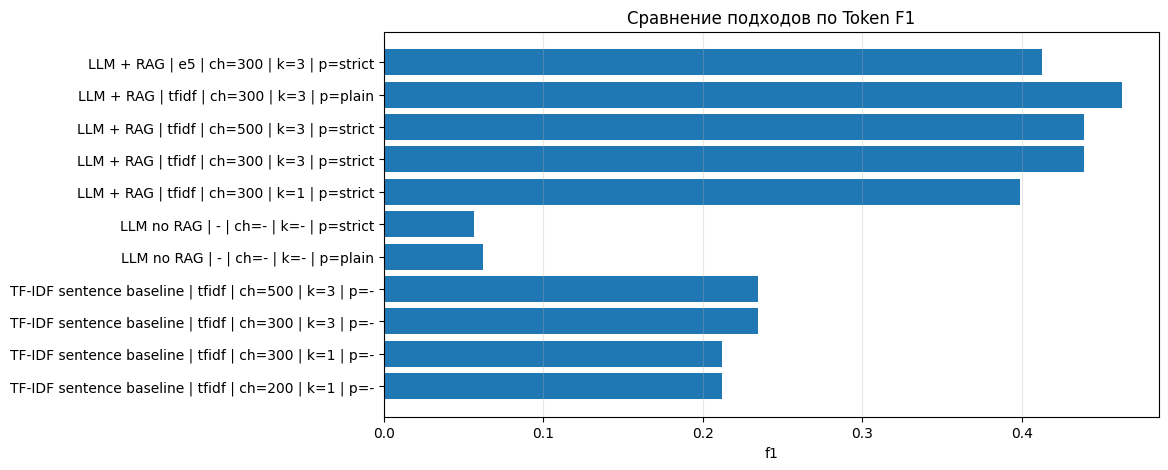

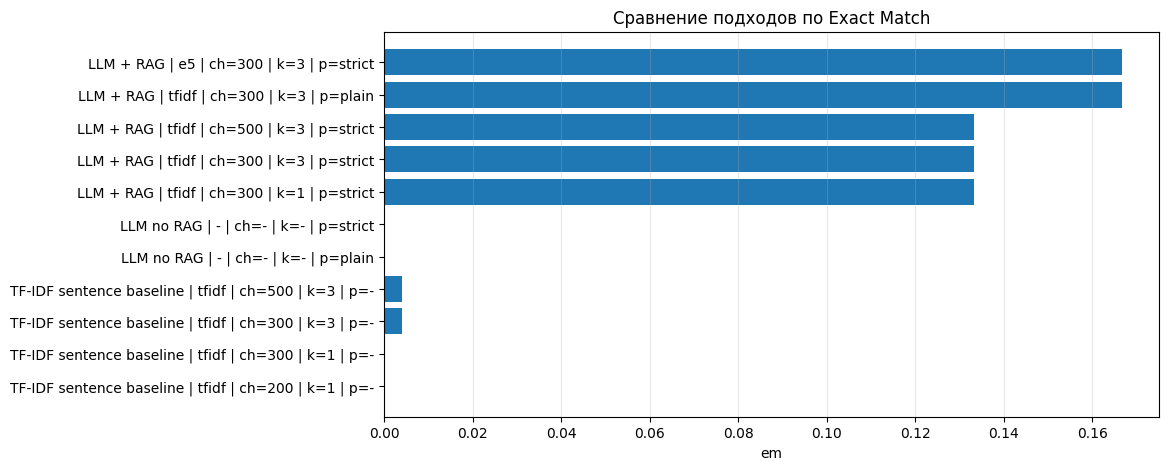

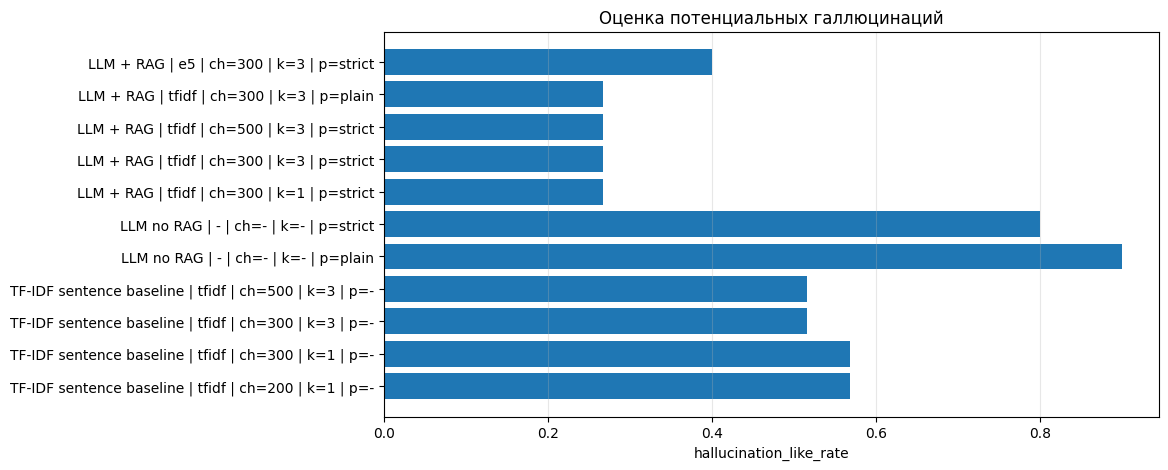

In [ ]:
if len(results_df) > 0:
    plot_df = results_df.copy()
    plot_df["label"] = (
        plot_df["method"].astype(str)
        + " | " + plot_df["retriever"].astype(str)
        + " | ch=" + plot_df["chunk_size"].astype(str)
        + " | k=" + plot_df["top_k"].astype(str)
        + " | p=" + plot_df["prompt_type"].astype(str)
    )

    for metric, title in [
        ("f1", "Сравнение подходов по Token F1"),
        ("em", "Сравнение подходов по Exact Match"),
        ("hallucination_like_rate", "Оценка потенциальных галлюцинаций"),
    ]:
        if metric in plot_df.columns:
            plt.figure(figsize=(10, 5))
            plt.barh(plot_df["label"], plot_df[metric])
            plt.xlabel(metric)
            plt.title(title)
            plt.grid(axis="x", alpha=0.3)
            plt.show()
else:
    print("results_df пустой, графики не построены.")

### Вывод по экспериментам

Всего было проведено **11 экспериментов**: несколько конфигураций TF-IDF baseline, два варианта LLM без RAG и несколько вариантов LLM + RAG с разными `chunk_size`, `top_k`, типами prompt и retrieval.

По итоговой таблице видно, что **LLM без RAG показала худшие результаты**. При ответе без контекста модель получила **EM = 0.0**, **Token F1 около 0.056–0.062**, а `hallucination_like_rate` составил **0.80–0.90**. Это означает, что без внешнего контекста модель часто даёт уверенный, но неподтверждённый ответ. Демонстрационный пример это хорошо показывает: на вопрос про Наруто модель без RAG ответила про «древних русских писателей», хотя правильный ответ — **Наруто Удзумаки**.

Простой TF-IDF baseline оказался лучше LLM без RAG по Token F1: лучший вариант дал **F1 = 0.2346**. При этом он хорошо находит релевантный контекст, особенно при `top_k=3`, где `retrieved_contains_answer_rate = 0.88`. Но baseline всё равно уступает RAG, потому что не умеет аккуратно сформулировать короткий ответ.

Лучший результат показал подход **LLM + RAG** с TF-IDF retrieval, `chunk_size=300`, `top_k=3`, `prompt_type=plain`, `temperature=0.0`: **EM = 0.1667**, **Token F1 = 0.4628**, `hallucination_like_rate = 0.2667`. Это примерно в два раза выше по F1, чем лучший TF-IDF baseline, и значительно лучше, чем LLM без RAG.

Также интересен вариант **LLM + RAG с E5 embeddings**. Он получил высокий `retrieved_contains_answer_rate = 0.9667`, то есть семантический retrieval чаще находил контекст с правильным ответом. Однако итоговый F1 составил **0.4127**, что ниже лучшего TF-IDF RAG. Это показывает, что хороший retrieval сам по себе ещё не гарантирует лучший итоговый ответ: важны также качество генерации, формулировка prompt и то, насколько модель точно извлекает span из найденного текста.

Главный результат эксперимента: **RAG действительно улучшил ответы LLM и снизил долю потенциальных галлюцинаций**. Модель стала отвечать не только из внутренних знаний, а с опорой на найденный контекст, поэтому качество выросло, а число неподтверждённых ответов уменьшилось.

## 12. Расширенные эксперименты

Так же исследуем уровень галлюцинаций в зависимости от:

- выбранных QA-метрик;
- популярности информации;
- языка: русский / английский;
- размера модели;
- наличия retrieval, то есть влияния RAG.

Основные эксперименты выше уже проверяют влияние retrieval. Ниже добавлены дополнительные небольшие исследования.


In [ ]:
# Общие вспомогательные функции для расширенных экспериментов

def build_chunk_corpus_from_df(df_source, chunk_size=300, overlap=50):
    temp = df_source.copy()
    if "context_id" not in temp.columns:
        temp["context_id"] = temp["context"].astype(str).factorize()[0]

    unique_contexts = (
        temp[["context_id", "context"]]
        .drop_duplicates("context_id")
        .reset_index(drop=True)
    )

    chunks = []
    for _, row in unique_contexts.iterrows():
        parts = chunk_text_by_words(row["context"], chunk_size=chunk_size, overlap=overlap)
        for i, part in enumerate(parts):
            chunks.append({
                "chunk_id": len(chunks),
                "context_id": int(row["context_id"]),
                "chunk_index": i,
                "text": part,
                "chunk_size": chunk_size,
                "overlap": overlap,
            })
    return pd.DataFrame(chunks)


def make_qa_df_from_rows(rows, source_name="manual", default_language="ru"):
    out = pd.DataFrame(rows).copy()
    out["context"] = out["context"].astype(str)
    out["question"] = out["question"].astype(str)
    out["answer"] = out["answer"].astype(str)
    if "language" not in out.columns:
        out["language"] = default_language
    if "source" not in out.columns:
        out["source"] = source_name
    out["context_id"] = out["context"].factorize()[0]
    return out.reset_index(drop=True)


def make_no_rag_prompt_lang(question, prompt_type="plain", language="ru"):
    if language == "en":
        if prompt_type == "strict":
            return (
                "Answer the question briefly. If you are not sure, write: No information.\n\n"
                f"Question: {question}\nAnswer:"
            )
        return f"Answer the question briefly.\n\nQuestion: {question}\nAnswer:"

    if prompt_type == "strict":
        return (
            "Ответь на вопрос кратко. Если ты не уверен в ответе, напиши: Нет информации.\n\n"
            f"Вопрос: {question}\nОтвет:"
        )
    return f"Ответь на вопрос кратко.\n\nВопрос: {question}\nОтвет:"


def make_rag_prompt_lang(question, context, prompt_type="strict", language="ru"):
    if language == "en":
        if prompt_type == "strict":
            return (
                "Answer the question only using the context below. "
                "If the context does not contain the answer, write: No information in context.\n\n"
                f"Context:\n{context}\n\n"
                f"Question:\n{question}\n\n"
                "Answer:"
            )
        return f"Context:\n{context}\n\nQuestion:\n{question}\n\nAnswer briefly:"

    return make_rag_prompt(question, context, prompt_type=prompt_type)


def evaluate_llm_no_rag_generic(df_eval, prompt_type="plain", temperature=0.0, default_language="ru"):
    rows = []
    if not RUN_LLM:
        return pd.DataFrame()

    for _, row in tqdm(df_eval.iterrows(), total=len(df_eval), desc="LLM no RAG generic"):
        language = row.get("language", default_language)
        prompt = make_no_rag_prompt_lang(row["question"], prompt_type=prompt_type, language=language)
        pred = generate_llm_response(prompt, temperature=temperature)
        rows.append({
            "context_id": int(row.get("context_id", -1)),
            "question": row["question"],
            "answer": row["answer"],
            "prediction": pred,
            "language": language,
            "popularity": row.get("popularity", "-"),
            "prompt_type": prompt_type,
            "temperature": temperature,
        })
    return evaluate_predictions(rows)


def evaluate_llm_rag_tfidf_on_corpus(df_eval, corpus_df=None, chunk_size=300, overlap=50, top_k=3, prompt_type="strict", temperature=0.0, default_language="ru"):
    rows = []
    if not RUN_LLM:
        return pd.DataFrame()

    corpus_df = df if corpus_df is None else corpus_df
    chunks_df = build_chunk_corpus_from_df(corpus_df, chunk_size=chunk_size, overlap=overlap)
    retriever = TfidfRetriever().fit(chunks_df)

    for _, row in tqdm(df_eval.iterrows(), total=len(df_eval), desc="LLM + TF-IDF RAG generic"):
        language = row.get("language", default_language)
        retrieved = retriever.search(row["question"], top_k=top_k)
        context = "\n\n".join([r["text"] for r in retrieved])
        prompt = make_rag_prompt_lang(row["question"], context, prompt_type=prompt_type, language=language)
        pred = generate_llm_response(prompt, temperature=temperature)

        rows.append({
            "context_id": int(row.get("context_id", -1)),
            "question": row["question"],
            "answer": row["answer"],
            "prediction": pred,
            "retrieved_text": context,
            "language": language,
            "popularity": row.get("popularity", "-"),
            "retrieved_contains_answer": int(any(contains_answer(r["text"], row["answer"]) for r in retrieved)),
            "correct_context_retrieved": int(any(int(r["context_id"]) == int(row.get("context_id", -1)) for r in retrieved)),
            "chunk_size": chunk_size,
            "top_k": top_k,
            "prompt_type": prompt_type,
            "temperature": temperature,
        })
    return evaluate_predictions(rows)


def aggregate_group_metrics(eval_df, group_cols):
    if eval_df is None or len(eval_df) == 0:
        return pd.DataFrame()
    rows = []
    for keys, part in eval_df.groupby(group_cols):
        if not isinstance(keys, tuple):
            keys = (keys,)
        row = {col: key for col, key in zip(group_cols, keys)}
        row.update({
            "n": len(part),
            "em": round(float(part["em"].mean()), 4),
            "f1": round(float(part["f1"].mean()), 4),
            "hallucination_like_rate": round(float(part["hallucination_like"].mean()), 4),
            "refusal_rate": round(float(part["prediction"].apply(is_no_info_answer).mean()), 4),
        })
        if "retrieved_contains_answer" in part.columns:
            row["retrieved_contains_answer_rate"] = round(float(part["retrieved_contains_answer"].mean()), 4)
        rows.append(row)
    return pd.DataFrame(rows)


### 12.1. Популярность информации

Идея эксперимента: LLM без RAG обычно лучше отвечает на **популярные общеизвестные факты**, потому что такие факты с высокой вероятностью встречались в обучающих данных модели. Но на контекстно-зависимых или низкопопулярных фактах модель без RAG может начать угадывать.

Поэтому создаём маленький контрольный набор:

- `popular` — общеизвестные факты;
- `context_specific` — факты, которые явно даны только в контексте учебного примера.

Для обеих групп сравниваем LLM без RAG и LLM + RAG.


In [ ]:
popular_rows = [
    {
        "popularity": "popular",
        "language": "ru",
        "context": "Столицей Франции является Париж. Франция расположена в Западной Европе.",
        "question": "Какая столица Франции?",
        "answer": "Париж",
    },
    {
        "popularity": "popular",
        "language": "ru",
        "context": "Роман 'Война и мир' написал Лев Николаевич Толстой.",
        "question": "Кто написал роман 'Война и мир'?",
        "answer": "Лев Николаевич Толстой",
    },
    {
        "popularity": "popular",
        "language": "ru",
        "context": "Первым человеком, совершившим полёт в космос, был Юрий Гагарин.",
        "question": "Кто был первым человеком в космосе?",
        "answer": "Юрий Гагарин",
    },
    {
        "popularity": "popular",
        "language": "ru",
        "context": "Химическая формула воды — H2O.",
        "question": "Какая химическая формула воды?",
        "answer": "H2O",
    },
    {
        "popularity": "context_specific",
        "language": "ru",
        "context": "В учебном корпусе проекта 'Север-12' руководителем группы была Елена Мартынова.",
        "question": "Кто был руководителем группы в проекте 'Север-12'?",
        "answer": "Елена Мартынова",
    },
    {
        "popularity": "context_specific",
        "language": "ru",
        "context": "В описании эксперимента 'Ладога-48' основной датчик назывался Терма-5.",
        "question": "Как назывался основной датчик в эксперименте 'Ладога-48'?",
        "answer": "Терма-5",
    },
    {
        "popularity": "context_specific",
        "language": "ru",
        "context": "В локальном архиве 'Кодекс-71' итоговый отчёт был подписан 14 марта 2018 года.",
        "question": "Когда был подписан итоговый отчёт в архиве 'Кодекс-71'?",
        "answer": "14 марта 2018 года",
    },
    {
        "popularity": "context_specific",
        "language": "ru",
        "context": "В демонстрационном наборе данных образец A-17 получил категорию 'северный профиль'.",
        "question": "Какую категорию получил образец A-17?",
        "answer": "северный профиль",
    },
]

popularity_df = make_qa_df_from_rows(popular_rows, source_name="manual_popularity", default_language="ru")
display(popularity_df[["popularity", "question", "answer", "context"]])

popularity_detailed = {}
popularity_summary = pd.DataFrame()

if RUN_EXTENDED_ANALYSIS and RUN_LLM:
    pop_no_rag = evaluate_llm_no_rag_generic(popularity_df.head(N_EVAL_POPULARITY), prompt_type="strict", temperature=0.0)
    pop_no_rag["method"] = "LLM no RAG"
    popularity_detailed["LLM no RAG popularity"] = pop_no_rag

    pop_rag = evaluate_llm_rag_tfidf_on_corpus(
        popularity_df.head(N_EVAL_POPULARITY),
        corpus_df=popularity_df,
        chunk_size=120,
        overlap=20,
        top_k=1,
        prompt_type="strict",
        temperature=0.0,
    )
    pop_rag["method"] = "LLM + RAG"
    popularity_detailed["LLM + RAG popularity"] = pop_rag

    popularity_all = pd.concat([pop_no_rag, pop_rag], ignore_index=True)
    popularity_summary = aggregate_group_metrics(popularity_all, ["popularity", "method"])
    display(popularity_summary)
else:
    print("Эксперимент по популярности пропущен: RUN_EXTENDED_ANALYSIS=False или RUN_LLM=False.")


,popularity,question,answer,context
0,popular,Какая столица Франции?,Париж,Столицей Франции является Париж. Франция расположена в Западной Европе.
1,popular,Кто написал роман 'Война и мир'?,Лев Николаевич Толстой,Роман 'Война и мир' написал Лев Николаевич Толстой.
2,popular,Кто был первым человеком в космосе?,Юрий Гагарин,"Первым человеком, совершившим полёт в космос, был Юрий Гагарин."
3,popular,Какая химическая формула воды?,H2O,Химическая формула воды — H2O.
4,context_specific,Кто был руководителем группы в проекте 'Север-12'?,Елена Мартынова,В учебном корпусе проекта 'Север-12' руководителем группы была Елена Мартынова.
5,context_specific,Как назывался основной датчик в эксперименте 'Ладога-48'?,Терма-5,В описании эксперимента 'Ладога-48' основной датчик назывался Терма-5.
6,context_specific,Когда был подписан итоговый отчёт в архиве 'Кодекс-71'?,14 марта 2018 года,В локальном архиве 'Кодекс-71' итоговый отчёт был подписан 14 марта 2018 года.
7,context_specific,Какую категорию получил образец A-17?,северный профиль,В демонстрационном наборе данных образец A-17 получил категорию 'северный профиль'.


LLM no RAG generic:   0%|          | 0/8 [00:00<?, ?it/s]

LLM + TF-IDF RAG generic:   0%|          | 0/8 [00:00<?, ?it/s]

,popularity,method,n,em,f1,hallucination_like_rate,refusal_rate,retrieved_contains_answer_rate
0,context_specific,LLM + RAG,4,1.00,1.0000,0.00,0.00,1.0
1,context_specific,LLM no RAG,4,0.00,0.0000,0.25,0.75,NaN
2,popular,LLM + RAG,4,0.75,0.8611,0.00,0.00,1.0
3,popular,LLM no RAG,4,0.00,0.1000,0.50,0.25,NaN


### Вывод по популярности информации

В дополнительном эксперименте сравнивались две группы вопросов: **popular** — общеизвестные факты, и **context_specific** — искусственно заданные факты, которые можно корректно восстановить только из предоставленного контекста.

По фактическим результатам видно, что **LLM + RAG стабильно оказался лучше LLM без RAG в обеих группах**. На контекстно-зависимых фактах RAG получил **EM = 1.00**, **Token F1 = 1.00**, `hallucination_like_rate = 0.00`, потому что retrieval передал модели короткий контекст с точным ответом. LLM без RAG на этих же примерах получила **EM = 0.00**, **F1 = 0.00**, но при этом `refusal_rate = 0.75`: модель чаще не выдумывала ответ, а отказывалась отвечать или не находила информацию во внутренних знаниях.

На популярных фактах RAG также сработал лучше: **EM = 0.75**, **F1 = 0.8611**, `hallucination_like_rate = 0.00`. LLM без RAG получила только **F1 = 0.10**, `hallucination_like_rate = 0.50` и `refusal_rate = 0.25`. То есть в данном запуске даже общеизвестные факты маленькая модель Qwen 0.5B не всегда воспроизводила строго и корректно. Это важный результат: популярность информации сама по себе не гарантирует правильный ответ, особенно для небольшой LLM и при строгой QA-оценке.

Главный вывод по этому блоку: **RAG снижает зависимость ответа от того, “знает” ли модель факт заранее**. Когда правильная информация явно передана в контексте, модель отвечает заметно точнее и почти не даёт неподтверждённых ответов.

### 12.2. Язык: русский / английский

Основной датасет проекта — русский SberQuAD. Добавим небольшой английский QA-набор на базе SQuAD и сравним качество на русском и английском при одинаковой логике:

- LLM без RAG;
- LLM + RAG;
- одинаковые метрики EM, Token F1 и hallucination-like rate;
- одинаковый `top_k=3` для RAG.

Этот блок является дополнительной проверкой устойчивости подхода на другом языке.


In [ ]:
def load_english_squad_df(max_examples=20, seed=SEED):
    last_error = None
    for dataset_name in EN_DATASET_CANDIDATES:
        try:
            try:
                raw_en = load_dataset(dataset_name, token=HF_TOKEN if HF_TOKEN else None)
            except TypeError:
                raw_en = load_dataset(dataset_name)

            split = "validation" if "validation" in raw_en else list(raw_en.keys())[0]
            ds_en = raw_en[split].shuffle(seed=seed).select(range(min(max_examples, len(raw_en[split]))))
            en_raw = ds_en.to_pandas()

            en_df = en_raw.copy()
            en_df["answer"] = en_df["answers"].apply(get_first_answer)
            en_df = en_df.dropna(subset=["context", "question", "answer"]).copy()
            en_df["context"] = en_df["context"].astype(str)
            en_df["question"] = en_df["question"].astype(str)
            en_df["answer"] = en_df["answer"].astype(str)
            en_df = en_df[en_df["answer"].str.strip().str.len() > 0].reset_index(drop=True)
            en_df["context_id"] = en_df["context"].factorize()[0]
            en_df["language"] = "en"
            en_df["source"] = dataset_name
            print(f"Английский датасет загружен: {dataset_name}, split={split}, examples={len(en_df)}")
            return en_df
        except Exception as e:
            last_error = e
            print(f"Не удалось загрузить {dataset_name}: {type(e).__name__}: {e}")

    print("Английский датасет не загружен. Последняя ошибка:", repr(last_error))
    return pd.DataFrame()


language_summary = pd.DataFrame()
language_detailed = {}

if RUN_EXTENDED_ANALYSIS:
    ru_language_df = llm_eval_df.head(min(N_EVAL_LANGUAGE, len(llm_eval_df))).copy()
    ru_language_df["language"] = "ru"
    ru_language_df["source"] = "SberQuAD"

    en_language_df = load_english_squad_df(max_examples=N_EVAL_LANGUAGE, seed=SEED)

    print("RU examples:", len(ru_language_df))
    print("EN examples:", len(en_language_df))

    if RUN_LLM and len(en_language_df) > 0 and len(ru_language_df) > 0:
        lang_parts = []
        for lang_name, lang_df in [("ru", ru_language_df), ("en", en_language_df)]:
            no_rag = evaluate_llm_no_rag_generic(lang_df, prompt_type="strict", temperature=0.0, default_language=lang_name)
            no_rag["method"] = "LLM no RAG"
            no_rag["language"] = lang_name
            language_detailed[f"{lang_name} LLM no RAG"] = no_rag
            lang_parts.append(no_rag)

            rag = evaluate_llm_rag_tfidf_on_corpus(
                lang_df,
                corpus_df=lang_df,
                chunk_size=300,
                overlap=50,
                top_k=3,
                prompt_type="strict",
                temperature=0.0,
                default_language=lang_name,
            )
            rag["method"] = "LLM + RAG"
            rag["language"] = lang_name
            language_detailed[f"{lang_name} LLM + RAG"] = rag
            lang_parts.append(rag)

        language_all = pd.concat(lang_parts, ignore_index=True)
        language_summary = aggregate_group_metrics(language_all, ["language", "method"])
        display(language_summary)
    else:
        print("Языковой LLM-эксперимент пропущен: RUN_LLM=False или английский датасет не загружен.")
else:
    print("RUN_EXTENDED_ANALYSIS=False, языковой эксперимент пропущен.")


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/14.5M [00:00<?, ?B/s]

plain_text/validation-00000-of-00001.par(…):   0%|          | 0.00/1.82M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/87599 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10570 [00:00<?, ? examples/s]

...

LLM no RAG generic:   0%|          | 0/20 [00:00<?, ?it/s]

LLM + TF-IDF RAG generic:   0%|          | 0/20 [00:00<?, ?it/s]

LLM no RAG generic:   0%|          | 0/20 [00:00<?, ?it/s]

LLM + TF-IDF RAG generic:   0%|          | 0/20 [00:00<?, ?it/s]

,language,method,n,em,f1,hallucination_like_rate,refusal_rate,retrieved_contains_answer_rate
0,en,LLM + RAG,20,0.25,0.3496,0.30,0.25,0.95
1,en,LLM no RAG,20,0.00,0.0171,0.45,0.50,NaN
2,ru,LLM + RAG,20,0.05,0.4339,0.35,0.00,1.00
3,ru,LLM no RAG,20,0.00,0.0541,0.85,0.15,NaN


### Вывод по языку

В языковом эксперименте сравнивались русский QA на SberQuAD и английский QA на SQuAD. Размер подвыборки был небольшим — по **20 примеров** на язык, поэтому результаты нужно рассматривать как дополнительную проверку, а не как полноценный multilingual benchmark.

На английском языке **LLM + RAG** получил **EM = 0.25**, **Token F1 = 0.3496**, `hallucination_like_rate = 0.30`, тогда как **LLM без RAG** получил **EM = 0.00**, **F1 = 0.0171**, `hallucination_like_rate = 0.45` и `refusal_rate = 0.50`. На русском языке **LLM + RAG** получил **EM = 0.05**, **F1 = 0.4339**, `hallucination_like_rate = 0.35`, а **LLM без RAG** — **EM = 0.00**, **F1 = 0.0541**, `hallucination_like_rate = 0.85`.

Таким образом, RAG улучшил качество на обоих языках. На английском выше Exact Match, а на русском выше Token F1. Это означает, что русские ответы чаще были близки по смыслу или частично совпадали с эталоном, но реже совпадали строго по формулировке. Отдельно видно, что LLM без RAG особенно плохо работала на русском QA: `hallucination_like_rate = 0.85`, то есть большинство ответов выглядели как неподтверждённые или не совпадающие с правильным ответом.

Вывод: **retrieval полезен независимо от языка**, потому что он добавляет в prompt фактический контекст. При этом сравнение языков зависит от конкретной модели, размера подвыборки и строгости метрик EM/F1.

### 12.3. Размер модели

Проверяем, как меняется качество при использовании моделей одной линейки, но разного размера:

- `Qwen/Qwen2.5-0.5B-Instruct`;
- `Qwen/Qwen2.5-1.5B-Instruct`.

Чтобы эксперимент не занимал слишком много времени, используем небольшую подвыборку `N_EVAL_MODEL_SIZE`. Сравниваем оба режима:

- LLM без RAG;
- LLM + RAG.

Важно: более крупная модель может давать лучшие ответы, но требует больше GPU-памяти и времени. Поэтому для учебного проекта этот блок сделан небольшим.


In [ ]:
def unload_current_llm():
    global llm_tokenizer, llm_model
    try:
        del llm_model
        del llm_tokenizer
    except Exception:
        pass
    llm_model = None
    llm_tokenizer = None
    gc.collect()
    try:
        import torch
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    except Exception:
        pass


def switch_llm_model(model_id):
    global LLM_MODEL_ID, llm_tokenizer, llm_model, RUN_LLM
    if not RUN_LLM:
        return None, None

    if llm_model is not None and LLM_MODEL_ID == model_id:
        print("Модель уже загружена:", model_id)
        return llm_tokenizer, llm_model

    print("Переключаем модель на:", model_id)
    unload_current_llm()
    LLM_MODEL_ID = model_id
    return load_llm_model()


model_size_summary = pd.DataFrame()
model_size_detailed = {}

if RUN_EXTENDED_ANALYSIS and RUN_LLM and RUN_MODEL_SIZE_COMPARISON:
    base_model_id_before_size_test = LLM_MODEL_ID
    size_eval_df = llm_eval_df.head(min(N_EVAL_MODEL_SIZE, len(llm_eval_df))).copy()
    size_parts = []

    for model_id in MODEL_SIZE_COMPARISON_IDS:
        try:
            switch_llm_model(model_id)

            no_rag = evaluate_llm_no_rag_generic(size_eval_df, prompt_type="strict", temperature=0.0, default_language="ru")
            no_rag["method"] = "LLM no RAG"
            no_rag["model_id"] = model_id
            model_size_detailed[f"{model_id} no RAG"] = no_rag
            size_parts.append(no_rag)

            rag = evaluate_llm_rag_tfidf_on_corpus(
                size_eval_df,
                corpus_df=df,
                chunk_size=300,
                overlap=50,
                top_k=3,
                prompt_type="strict",
                temperature=0.0,
                default_language="ru",
            )
            rag["method"] = "LLM + RAG"
            rag["model_id"] = model_id
            model_size_detailed[f"{model_id} RAG"] = rag
            size_parts.append(rag)
        except Exception as e:
            print(f"Эксперимент с моделью {model_id} пропущен из-за ошибки: {type(e).__name__}: {e}")

    if size_parts:
        model_size_all = pd.concat(size_parts, ignore_index=True)
        model_size_summary = aggregate_group_metrics(model_size_all, ["model_id", "method"])
        display(model_size_summary)

    # Возвращаем базовую модель, чтобы следующие демонстрационные ячейки работали как раньше.
    try:
        switch_llm_model(base_model_id_before_size_test)
    except Exception as e:
        print("Не удалось вернуть базовую модель:", type(e).__name__, e)
else:
    print("Эксперимент по размеру модели пропущен: RUN_EXTENDED_ANALYSIS=False, RUN_LLM=False или RUN_MODEL_SIZE_COMPARISON=False.")


Модель уже загружена: Qwen/Qwen2.5-0.5B-Instruct


LLM no RAG generic:   0%|          | 0/10 [00:00<?, ?it/s]

LLM + TF-IDF RAG generic:   0%|          | 0/10 [00:00<?, ?it/s]

Переключаем модель на: Qwen/Qwen2.5-1.5B-Instruct
Загружаю LLM: Qwen/Qwen2.5-1.5B-Instruct


tokenizer_config.json: 0.00B [00:00, ?B/s]

...

LLM загружена.


LLM no RAG generic:   0%|          | 0/10 [00:00<?, ?it/s]

LLM + TF-IDF RAG generic:   0%|          | 0/10 [00:00<?, ?it/s]

,model_id,method,n,em,f1,hallucination_like_rate,refusal_rate,retrieved_contains_answer_rate
0,Qwen/Qwen2.5-0.5B-Instruct,LLM + RAG,10,0.1,0.4644,0.2,0.2,0.9
1,Qwen/Qwen2.5-0.5B-Instruct,LLM no RAG,10,0.0,0.0474,1.0,0.0,NaN
2,Qwen/Qwen2.5-1.5B-Instruct,LLM + RAG,10,0.0,0.3041,0.2,0.2,0.9
3,Qwen/Qwen2.5-1.5B-Instruct,LLM no RAG,10,0.0,0.0000,0.0,1.0,NaN


Переключаем модель на: Qwen/Qwen2.5-0.5B-Instruct
Загружаю LLM: Qwen/Qwen2.5-0.5B-Instruct
LLM загружена.


### Вывод по размеру модели

В эксперименте по размеру модели сравнивались две модели одной линейки: **Qwen2.5-0.5B-Instruct** и **Qwen2.5-1.5B-Instruct**. Подвыборка была небольшой — **10 примеров**, поэтому выводы здесь являются дополнительными и не должны трактоваться как окончательный benchmark моделей.

Для **Qwen 0.5B + RAG** получено **EM = 0.10**, **Token F1 = 0.4644**, `hallucination_like_rate = 0.20`, `refusal_rate = 0.20`. Для **Qwen 1.5B + RAG** получено **EM = 0.00**, **F1 = 0.3041**, `hallucination_like_rate = 0.20`, `refusal_rate = 0.20`. В этом запуске более крупная модель не дала лучшего результата: при одинаковом retrieval меньшая модель показала более высокий Token F1.

Без RAG обе модели работали слабо, но по-разному. **Qwen 0.5B без RAG** получил **F1 = 0.0474** и `hallucination_like_rate = 1.00`, то есть почти все ответы были неподтверждёнными. **Qwen 1.5B без RAG** получил **F1 = 0.00**, но `refusal_rate = 1.00`: модель фактически отказалась отвечать на все вопросы, поэтому автоматическая hallucination-like rate стала 0.00, но качество ответа не улучшилось.

Главный вывод: **увеличение размера модели само по себе не решило задачу QA**. В данном случае более важным фактором оказался не размер LLM, а наличие релевантного контекста через RAG. Большая модель может быть осторожнее и чаще отказываться, но без retrieval она всё равно не получает нужную информацию из конкретного датасета.

In [ ]:
# Сводная таблица расширенных экспериментов
extended_tables = []

if len(popularity_summary) > 0:
    t = popularity_summary.copy()
    t["analysis"] = "popularity"
    extended_tables.append(t)

if len(language_summary) > 0:
    t = language_summary.copy()
    t["analysis"] = "language"
    extended_tables.append(t)

if len(model_size_summary) > 0:
    t = model_size_summary.copy()
    t["analysis"] = "model_size"
    extended_tables.append(t)

if extended_tables:
    extended_results_df = pd.concat(extended_tables, ignore_index=True, sort=False)
    display(extended_results_df)
    extended_results_path = "nlp_rag_qa_extended_results.csv"
    extended_results_df.to_csv(extended_results_path, index=False, encoding="utf-8-sig")
    print("Расширенная таблица результатов сохранена:", extended_results_path)
else:
    extended_results_df = pd.DataFrame()
    print("Расширенные результаты отсутствуют или были пропущены.")


,popularity,method,n,em,f1,hallucination_like_rate,refusal_rate,retrieved_contains_answer_rate,analysis,language,model_id
0,context_specific,LLM + RAG,4,1.00,1.0000,0.00,0.00,1.00,popularity,NaN,NaN
1,context_specific,LLM no RAG,4,0.00,0.0000,0.25,0.75,NaN,popularity,NaN,NaN
2,popular,LLM + RAG,4,0.75,0.8611,0.00,0.00,1.00,popularity,NaN,NaN
3,popular,LLM no RAG,4,0.00,0.1000,0.50,0.25,NaN,popularity,NaN,NaN
4,NaN,LLM + RAG,20,0.25,0.3496,0.30,0.25,0.95,language,en,NaN
5,NaN,LLM no RAG,20,0.00,0.0171,0.45,0.50,NaN,language,en,NaN
6,NaN,LLM + RAG,20,0.05,0.4339,0.35,0.00,1.00,language,ru,NaN
7,NaN,LLM no RAG,20,0.00,0.0541,0.85,0.15,NaN,language,ru,NaN
8,NaN,LLM + RAG,10,0.10,0.4644,0.20,0.20,0.90,model_size,NaN,Qwen/Qwen2.5-0.5B-Instruct
9,NaN,LLM no RAG,10,0.00,0.0474,1.00,0.00,NaN,model_size,NaN,Qwen/Qwen2.5-0.5B-Instruct


Расширенная таблица результатов сохранена: nlp_rag_qa_extended_results.csv


### Вывод по расширенным экспериментам

Расширенные эксперименты были проведены по следующим пунктам: разные QA-метрики, популярность информации, русский/английский язык, размер модели и влияние retrieval на галлюцинации.

**Метрики QA.** В проекте использовалось несколько метрик, потому что одной метрики недостаточно. **Exact Match** показывает строгое совпадение с эталоном, но для генеративной LLM он слишком жёсткий: правильный по смыслу ответ может отличаться формулировкой и получить 0. **Token F1** лучше отражает частичное совпадение ответа с эталоном, поэтому он выбран как основная метрика качества. Для RAG отдельно важен **Recall@k / `retrieved_contains_answer_rate`**, потому что если правильный ответ не попал в найденный контекст, LLM почти не сможет ответить корректно. **Hallucination-like rate** используется как приближённая автоматическая оценка неподтверждённых ответов, а **refusal rate** помогает отделить галлюцинации от отказов.

**Популярность информации.** На popular-фактах LLM без RAG не показала высокого качества: **F1 = 0.10**, `hallucination_like_rate = 0.50`. На context-specific фактах LLM без RAG получила **F1 = 0.00**, но чаще отказывалась отвечать (`refusal_rate = 0.75`). RAG в обеих группах резко улучшил результаты: на context-specific фактах **F1 = 1.00**, на popular-фактах **F1 = 0.8611**, а hallucination-like rate в обоих случаях равен **0.00**. Значит, наличие контекста оказалось важнее, чем предположение о популярности факта.

**Язык.** На русском и английском языках RAG улучшил качество относительно LLM без RAG. Для английского QA RAG дал **F1 = 0.3496** против **0.0171** без RAG. Для русского QA RAG дал **F1 = 0.4339** против **0.0541** без RAG. При этом русская LLM без RAG имела очень высокий `hallucination_like_rate = 0.85`, а RAG снизил его до **0.35**. Следовательно, retrieval полезен на обоих языках, хотя конкретные значения зависят от датасета и формулировок ответов.

**Размер модели.** Сравнение Qwen 0.5B и Qwen 1.5B не показало, что более крупная модель автоматически лучше. На маленькой подвыборке **Qwen 0.5B + RAG** получил **F1 = 0.4644**, а **Qwen 1.5B + RAG** — **F1 = 0.3041**. Без RAG обе модели не дали хороших ответов: 0.5B чаще галлюцинировала, а 1.5B чаще отказывалась отвечать. Поэтому главный фактор качества в этой работе — не только размер модели, а наличие релевантного retrieval-контекста.

Общий вывод расширенных экспериментов: **RAG снижает галлюцинации и повышает качество QA более стабильно, чем простое использование LLM без контекста**. При этом качество RAG-системы зависит от retrieval, prompt, языка, строгости метрик и поведения конкретной модели.

## 13. Анализ ошибок

Смотрим примеры, где методы ошиблись сильнее всего.

Цель анализа ошибок — понять не только какой подход лучше по числам, но и **почему** возникают ошибки:

- retrieval не нашёл нужный фрагмент;
- правильный фрагмент найден, но LLM извлекла не тот span;
- LLM без RAG дала уверенный неподтверждённый ответ;
- ответ частично правильный, но строгие QA-метрики поставили низкий балл из-за другой формулировки.


In [ ]:
# Выбираем лучший метод по F1 из таблицы и смотрим его ошибки.
if len(results_df) > 0 and len(all_detailed) > 0:
    # Находим имя детального результата приблизительно по лучшей строке.
    best_row = results_df.sort_values("f1", ascending=False).iloc[0]
    print("Лучшая строка по F1:")
    display(best_row.to_frame().T)

    # Для анализа покажем ошибки из всех сохранённых детальных результатов.
    for name, detail_df in all_detailed.items():
        if len(detail_df) == 0:
            continue
        print("\n" + "=" * 100)
        print("Метод:", name)
        err_cols = ["question", "answer", "prediction", "f1", "em", "hallucination_like"]
        if "retrieved_contains_answer" in detail_df.columns:
            err_cols.append("retrieved_contains_answer")
        if "retrieved_text" in detail_df.columns:
            err_cols.append("retrieved_text")
        display(detail_df.sort_values(["f1", "em"], ascending=[True, True])[err_cols].head(5))
else:
    print("Нет детальных результатов для анализа ошибок.")

Лучшая строка по F1:


,method,n,em,f1,hallucination_like_rate,refusal_rate,avg_prediction_words,retrieved_contains_answer_rate,correct_context_retrieved_rate,retriever,chunk_size,top_k,prompt_type,temperature
9,LLM + RAG,30,0.1667,0.4628,0.2667,0.0,7.07,0.8667,0.8667,tfidf,300,3,plain,0.0



Метод: TF-IDF baseline chunk=200 top_k=1


,question,answer,prediction,f1,em,hallucination_like,retrieved_contains_answer,retrieved_text
3,Кем работал Пьер Кюри на момент встречи с Склодовской?,руководителем лаборатории,В 1903 году Мария и Пьер Кюри совместно с Анри Беккерелем получили Нобелевскую премию по физике за выдающиеся заслуги в совместных исследованиях явлений радиации .,0.0,0,1,0,В 1903 году Мария и Пьер Кюри совместно с Анри Беккерелем получили Нобелевскую премию по физике за выдающиеся заслуги в совместных исследованиях явлений радиации . (Теперь они наконец получили возможность оснастить свою лабораторию необходимой ап...
4,На какие марки подразделяется висмут?,"Ви2, Ви1, Ви00, Ви000[13], Ви0000",Средневзвешенная цена на мировом рынке на конец 2016 г.,0.0,0,1,1,"В зависимости от степени чистоты металла висмут разделяют на несколько марок. В порядке увеличения степени чистоты это марки Ви2, Ви1, Ви00, Ви000[13], Ви0000[13]. ГОСТ 10928-90 нормирует содержание примесей в этих марках не более 2 %, 3 % и 0,02..."
6,Что входит в два механизма природы бессознательного?,1) комбинирование элементов будущих идей и 2) отбор полезных комбинаций,Улучшение человеческой природы через изучение античной литературы — краеугольный камень ренессансного гуманизма.,0.0,0,1,0,"Философы Возрождения от Эразма до Монтеня преклонялись перед разумом и его творческой мощью. Разум — это бесценный дар природы, который отличает человека от всего сущего, делает его богоподобным. Для гуманиста мудрость являлась высшим благом, дос..."
9,Почему мосты со стрельчатыми арками быстро потеряли популярность?,неоправданно увеличивал высоту моста,В Средние века двумя преобладающими типами стали мосты с полуциркульными (или круговыми) арками и мосты со стрельчатыми арками.,0.0,0,1,1,"В Средние века двумя преобладающими типами стали мосты с полуциркульными (или круговыми) арками и мосты со стрельчатыми арками. Первый тип основывался на римской традиции, второй был заимствован из восточной архитектуры и вскоре потерял популярно..."
20,Какой недостаток системы признавал сам Линней?,Искусственный характер,Также в 1739 году Линней принял участие в образовании Шведской королевской академии наук (которая в первые годы своего существования была частным обществом) и стал первым её президентом (председателем).,0.0,0,1,0,"В 1739 году Линнею было ассигновано парламентом ежегодное денежное содержание, при этом он брал на себя обязательство читать лекции по ботанике и минералогии; одновременно с этим Линней получил звание королевского ботаника . В этом же году Линней..."



Метод: TF-IDF baseline chunk=300 top_k=1


...

,question,answer,prediction,f1,em,hallucination_like,retrieved_contains_answer,retrieved_text
1,Какие исследования выпускают независимые аналитические агентства?,"по акциям компаний, валютному рынку, деривативам, вкладам, ПИФам","Еженедельный обзор модельных портфелей, ежедневные обзоры рынка, отраслевые обзоры",0.0,0,1,1,"Таким образом, основными предпосылками появления независимой аналитики было растущее недоверие инвесторов к аналитике, выпускаемой штатными подразделениями инвестиционных банков и брокеров, а также понимание необходимости регулирования ситуации н..."
6,Что входит в два механизма природы бессознательного?,1) комбинирование элементов будущих идей и 2) отбор полезных комбинаций,Нет информации в контексте.,0.0,0,0,0,"Философы Возрождения от Эразма до Монтеня преклонялись перед разумом и его творческой мощью. Разум — это бесценный дар природы, который отличает человека от всего сущего, делает его богоподобным. Для гуманиста мудрость являлась высшим благом, дос..."
9,Почему мосты со стрельчатыми арками быстро потеряли популярность?,неоправданно увеличивал высоту моста,Нет информации в контексте.,0.0,0,0,1,"В Средние века двумя преобладающими типами стали мосты с полуциркульными (или круговыми) арками и мосты со стрельчатыми арками. Первый тип основывался на римской традиции, второй был заимствован из восточной архитектуры и вскоре потерял популярно..."
12,С помощью чего могут быть изменены вариации ВМП?,При помощи спутниковой альтиметрии.,Циркуляция океана,0.0,0,1,1,"Поскольку гравитационное поле Земли относительно стабильно в масштабах десятилетий и столетий, циркуляция океана играет более значительную роль в наблюдаемой изменчивости ВМП. Сезонные изменения в распределении тепла и ветрового воздействия влияю..."
17,Какой двигатель могут использовать современные локомотивы?,трёхфазный двигатель или двигатель на постоянном токе,Трансформатор в локомотиве,0.0,0,1,1,"Электровозы получают энергию из стационарного источника через воздушную контактную сеть или контактный рельс. Некоторые в дополнении или вместо этого используют батарею. В локомотивах, работающих на высоковольтном переменном токе, трансформатор в..."



Метод: LLM RAG TFIDF chunk=300 top_k=3 prompt=plain


,question,answer,prediction,f1,em,hallucination_like,retrieved_contains_answer,retrieved_text
1,Какие исследования выпускают независимые аналитические агентства?,"по акциям компаний, валютному рынку, деривативам, вкладам, ПИФам","Независимые аналитические агентства выпускают еженедельные обзоры рынка, отраслевые обзоры, еженедельные моделиные портфели, ежедневные обзоры рынка, а также еженедель",0.0,0,1,1,"Таким образом, основными предпосылками появления независимой аналитики было растущее недоверие инвесторов к аналитике, выпускаемой штатными подразделениями инвестиционных банков и брокеров, а также понимание необходимости регулирования ситуации н..."
9,Почему мосты со стрельчатыми арками быстро потеряли популярность?,неоправданно увеличивал высоту моста,"Стрельчатые арки были более безопасными и эстетически подходящими для мостов, что привело к их утрате популярности.",0.0,0,1,1,"В Средние века двумя преобладающими типами стали мосты с полуциркульными (или круговыми) арками и мосты со стрельчатыми арками. Первый тип основывался на римской традиции, второй был заимствован из восточной архитектуры и вскоре потерял популярно..."
12,С помощью чего могут быть изменены вариации ВМП?,При помощи спутниковой альтиметрии.,Циркуляция океана и ВМП,0.0,0,1,1,"Поскольку гравитационное поле Земли относительно стабильно в масштабах десятилетий и столетий, циркуляция океана играет более значительную роль в наблюдаемой изменчивости ВМП. Сезонные изменения в распределении тепла и ветрового воздействия влияю..."
14,Каковы идеи Аристотеля о природе?,"Образования всего существующего из четырёх элементов (огня, земли, воды и воздуха).","Аристотель рассматривал природу металлов как сложность, требующую искусственного преобразования. Он предполагал, что металлы могут быть превращены в другого, создавая их искусственно.",0.0,0,1,1,"Ни одно из химических производств не способствовало столько развитию химических знаний, как процессы, связанные с получением и обработкой металлов; с историей их связаны важнейшие моменты истории химии. Свойства металлов так характерны, что уже в..."
20,Какой недостаток системы признавал сам Линней?,Искусственный характер,Недостаток - нехватка информации о его личном опыте и профессиональной деятельности.,0.0,0,1,0,"Лунд был ближайшим к Векшё городом, в котором было высшее учебное заведение. В 1727 году Линней сдал экзамены и был зачислен в Лундский университет под латинизированным именем Carolus Linnaeus. Помощь в соблюдении формальностей при зачислении ему..."



Метод: LLM RAG E5


,question,answer,prediction,f1,em,hallucination_like,retrieved_contains_answer,retrieved_text
1,Какие исследования выпускают независимые аналитические агентства?,"по акциям компаний, валютному рынку, деривативам, вкладам, ПИФам","Еженедельный обзор моделиных портфелей, ежедневные обзоры рынка, отраслевые обзоры.",0.0,0,1,1,"Таким образом, основными предпосылками появления независимой аналитики было растущее недоверие инвесторов к аналитике, выпускаемой штатными подразделениями инвестиционных банков и брокеров, а также понимание необходимости регулирования ситуации н..."
6,Что входит в два механизма природы бессознательного?,1) комбинирование элементов будущих идей и 2) отбор полезных комбинаций,Четыре частицы участвуют в бессознательном комбинировании.,0.0,0,1,1,"Размышляя о природе бессознательной фазы творческого процесса (на примере математического творчества), Пуанкаре представляет её как результат работы двух механизмов, осуществляющих 1) комбинирование элементов будущих идей и 2) отбор полезных комб..."
9,Почему мосты со стрельчатыми арками быстро потеряли популярность?,неоправданно увеличивал высоту моста,Нет информации в контексте.,0.0,0,0,1,"В Средние века двумя преобладающими типами стали мосты с полуциркульными (или круговыми) арками и мосты со стрельчатыми арками. Первый тип основывался на римской традиции, второй был заимствован из восточной архитектуры и вскоре потерял популярно..."
12,С помощью чего могут быть изменены вариации ВМП?,При помощи спутниковой альтиметрии.,"Сезонные изменения в распределении тепла и ветрового воздействия влияют на циркуляцию океана, а та, в свою очередь, на ВМП.",0.0,0,1,1,"Поскольку гравитационное поле Земли относительно стабильно в масштабах десятилетий и столетий, циркуляция океана играет более значительную роль в наблюдаемой изменчивости ВМП. Сезонные изменения в распределении тепла и ветрового воздействия влияю..."
13,В каком собрании текстов в наиболее яркой форме проявился христианский неоплатонизм?,в Ареопагитиках,Ареопагитика,0.0,0,1,1,"Христианский неоплатонизм в наиболее яркой форме проявился в Ареопагитиках, находящихся в очевидной зависимости от философии Прокла. В византийской философии идеи неоплатонизма получили большое распространение уже в период ранней патристики (IV в..."


### Вывод по ошибкам

Анализ ошибок показал, что ошибки распределяются по нескольким типам.

Первый тип — **ошибки retrieval**. Иногда система находит нерелевантный или неполный фрагмент, поэтому даже LLM с RAG не получает нужной информации. Например, если правильный ответ отсутствует в найденном top-k контексте, модель либо отвечает неправильно, либо пишет, что информации нет.

Второй тип — **неточное извлечение ответа из правильного контекста**. В ряде случаев retrieval нашёл фрагмент, где содержится правильный ответ, но LLM сформулировала ответ слишком широко или выбрала не тот кусок. Например, вместо точного ответа «При помощи спутниковой альтиметрии» модель могла ответить более общо: «циркуляция океана и ВМП». Формально такой ответ связан с темой контекста, но не совпадает с эталонным ответом.

Третий тип — **галлюцинации или неподтверждённые формулировки**. Это особенно заметно у LLM без RAG: модель отвечала уверенно, но факт не следовал из исходного текста. В демонстрационном примере LLM без RAG ошибочно ответила, что сёнэн-предшественниками являются «древние русские писатели», тогда как правильный ответ в контексте — «Наруто Удзумаки».

Четвёртый тип — **проблема строгих QA-метрик**. Exact Match и Token F1 требуют близкого совпадения с эталонной формулировкой. Поэтому ответ может быть частично правильным по смыслу, но получать низкий балл, если он слишком длинный, содержит лишние слова или отличается по форме. Это особенно видно у TF-IDF baseline, который часто возвращает длинное предложение с правильным ответом внутри.

В целом анализ ошибок подтверждает общий вывод: RAG уменьшает число грубых галлюцинаций, но качество всей системы всё ещё зависит от двух этапов — насколько хорошо retrieval нашёл контекст и насколько точно LLM извлекла из него короткий ответ.

## 14. Демонстрация одного полного примера

Здесь видно, как один и тот же вопрос проходит через разные подходы:

1. исходный вопрос и правильный ответ;
2. найденный RAG-контекст;
3. ответ TF-IDF baseline;
4. ответ LLM без RAG;
5. ответ LLM + RAG.


In [ ]:
def show_full_example(example_index=0):
    row = llm_eval_df.iloc[example_index] if len(llm_eval_df) else eval_df.iloc[example_index]

    print("Вопрос:")
    print(row["question"])
    print("\nПравильный ответ:")
    print(row["answer"])
    print("\nИсходный контекст, начало:")
    print(row["context"][:1200], "...")

    chunks_df = build_chunk_corpus(df, chunk_size=300, overlap=50)
    retriever = TfidfRetriever().fit(chunks_df)
    retrieved = retriever.search(row["question"], top_k=3)
    rag_context = "\n\n".join([r["text"] for r in retrieved])

    print("\nНайденный RAG-контекст:")
    print(rag_context[:1200], "...")

    baseline_pred = choose_best_sentence(row["question"], rag_context)
    print("\nTF-IDF baseline answer:")
    print(baseline_pred)

    if RUN_LLM:
        no_rag = generate_llm_response(make_no_rag_prompt(row["question"], "plain"), temperature=0.0)
        rag = generate_llm_response(make_rag_prompt(row["question"], rag_context, "strict"), temperature=0.0)
        print("\nLLM без RAG:")
        print(no_rag)
        print("\nLLM + RAG:")
        print(rag)
    else:
        print("\nLLM-ответы не показаны, потому что RUN_LLM=False.")

show_full_example(0)

Вопрос:
Кто сочетает в себе образы своих сёнэн-предшественников ?

Правильный ответ:
Наруто Удзумаки

Исходный контекст, начало:
По мнению рецензента сайта T.H.E.M. Anime Reviews персонажи Наруто являются отражением царящих в сёнэн-манге стереотипов и некоторые из них даже не симпатичны[37]. Однако другой обзор этого же сайта оценивает мангу в более радужных тонах, отмечая, что Наруто Удзумаки сочетает в себе образы своих сёнэн-предшественников , но сетуя, что некоторые персонажи находятся между харизмой и хладнокровием Наруто и невыразительностью Саскэ, что не позволяет думать о их каком-либо глубоком либо содержательном уровне [38]. ...

Найденный RAG-контекст:
По мнению рецензента сайта T.H.E.M. Anime Reviews персонажи Наруто являются отражением царящих в сёнэн-манге стереотипов и некоторые из них даже не симпатичны[37]. Однако другой обзор этого же сайта оценивает мангу в более радужных тонах, отмечая, что Наруто Удзумаки сочетает в себе образы своих сёнэн-предшественников , но сет

## 15. Итоговые выводы

В проекте была исследована задача **Question Answering по текстовому контексту** и влияние Retrieval-Augmented Generation на качество ответов и уровень галлюцинаций. Сравнивались четыре основных варианта: **TF-IDF sentence baseline**, **LLM без RAG**, **LLM + RAG с TF-IDF retrieval** и **LLM + RAG с E5 embedding retrieval**. Дополнительно были проведены расширенные эксперименты по популярности информации, языку и размеру модели.

Основной датасет — **SberQuAD**. Для экспериментов был выбран split `validation`, из которого взято **1500 примеров**. Основные retrieval/baseline эксперименты оценивались на **250 вопросах**, а LLM-эксперименты — на **30 вопросах**, так как генерация ответов существенно медленнее обычного поиска.

По основной таблице результатов лучший итоговый вариант — **LLM + RAG с TF-IDF retrieval**, `chunk_size=300`, `top_k=3`, `prompt_type=plain`, `temperature=0.0`. Он получил **EM = 0.1667**, **Token F1 = 0.4628**, `hallucination_like_rate = 0.2667`. Это лучший результат по Token F1 среди основных экспериментов. По EM лучший результат также у RAG-подходов: **0.1667**.

**TF-IDF sentence baseline** оказался полезной, но ограниченной точкой отсчёта. Лучший вариант baseline дал **F1 = 0.2346** и `retrieved_contains_answer_rate = 0.88`. Это показывает, что простой лексический поиск часто находит фрагмент с правильным ответом. Однако baseline возвращает длинные предложения или фрагменты, а не точный короткий ответ, поэтому Exact Match почти нулевой, а Token F1 остаётся заметно ниже, чем у LLM + RAG.

**LLM без RAG** показала худший результат. При обычном prompt она получила **F1 = 0.0621**, `hallucination_like_rate = 0.90`; при строгом prompt — **F1 = 0.0564**, `hallucination_like_rate = 0.80`, `refusal_rate = 0.1667`. Это подтверждает основную проблему: если LLM не получает исходный контекст, она отвечает из внутренних знаний, угадывает или отказывается, поэтому качество QA по конкретному датасету остаётся низким.

**LLM + RAG** заметно улучшила качество по сравнению с LLM без контекста. Лучший RAG-вариант повысил Token F1 примерно с **0.06** до **0.46** и снизил hallucination-like rate примерно с **0.80–0.90** до **0.2667**. Это главный результат проекта: retrieval добавляет в prompt релевантный текст, и модель начинает отвечать не “из памяти”, а с опорой на найденный контекст.

**Embedding retrieval на E5** показал самый высокий `retrieved_contains_answer_rate = 0.9667`, то есть чаще находил чанки с правильным ответом. Однако итоговый **F1 = 0.4127**, что ниже лучшего TF-IDF RAG. Это важное наблюдение: качество retrieval — необходимое, но не единственное условие хорошего QA. Даже если правильный контекст найден, LLM может неточно извлечь ответ, добавить лишние слова или выбрать не тот фрагмент.

В работе использовались разные QA-метрики. **Exact Match** полезен как строгая метрика, но слишком жёсткий для генеративных ответов. **Token F1** лучше отражает частичные совпадения и поэтому выбран как основная метрика. **Recall@k / retrieved_contains_answer_rate** показывает качество retrieval-этапа. **Hallucination-like rate** используется как приближённая автоматическая оценка неподтверждённых ответов, а **refusal rate** показывает, как часто модель отказывается отвечать вместо генерации ответа.

Расширенный анализ показал, что RAG полезен и в дополнительных условиях. На популярных фактах **LLM + RAG** получил **F1 = 0.8611**, а LLM без RAG — только **0.10**. На контекстно-зависимых фактах RAG получил **F1 = 1.00**, а LLM без RAG — **0.00**. В языковом сравнении RAG улучшил результаты и на английском, и на русском: английский F1 вырос с **0.0171** до **0.3496**, русский F1 — с **0.0541** до **0.4339**. Сравнение размера модели показало, что **Qwen 1.5B** не стала автоматически лучше **Qwen 0.5B**: на маленькой подвыборке 0.5B + RAG дал **F1 = 0.4644**, а 1.5B + RAG — **0.3041**. Это подтверждает, что в данной задаче наличие релевантного контекста важнее простого увеличения числа параметров.

За счёт чего выигрывает лучший метод: **LLM + RAG объединяет сильные стороны retrieval и генерации**. Retrieval находит фрагмент, где с высокой вероятностью есть ответ, а LLM преобразует этот фрагмент в короткий ответ на естественном языке. Поэтому система работает лучше, чем чистый поиск, и надёжнее, чем LLM без контекста.

Ограничения подходов:

- **TF-IDF baseline** зависит от совпадения слов между вопросом и текстом. Он плохо работает при переформулировках и обычно возвращает слишком длинный фрагмент вместо точного ответа.
- **LLM без RAG** не видит исходный контекст и поэтому склонна отвечать из памяти, угадывать, галлюцинировать или отказываться от ответа.
- **LLM + RAG** зависит от качества retrieval. Если top-k чанки не содержат правильного ответа или содержат много шума, модель может ошибиться даже при хорошем prompt.
- **Embedding retrieval** требует больше вычислительных ресурсов, чем TF-IDF. Кроме того, высокий Recall@k не гарантирует лучший итоговый ответ, потому что генерация остаётся отдельным источником ошибок.
- **Более крупная LLM** требует больше GPU-памяти и времени, но не обязательно даёт лучший результат без правильного retrieval-контекста.

Итог: в рамках данного проекта гипотеза подтвердилась. **RAG заметно повышает качество ответов и снижает уровень потенциальных галлюцинаций по сравнению с LLM без внешнего контекста**. При этом система остаётся неидеальной: качество зависит от retrieval, prompt, размера подвыборки, языка и строгости выбранных QA-метрик.